## **Customer Churn Prediction**

### Problem

#### Problem and Data

Develop a machine learning-based customer churn prediction engine that uses historical customer data to identify customers at higher risk of leaving, evaluate model performance, and support data-driven customer retention decisions.

#### ML Objective

Train and evaluate a binary classification model to predict the Churn outcome for unseen customers using their demographic, service, contract, payment, tenure, and billing-related features.

### Data

#### Dataset Acquisition

This project uses the **IBM Telco Customer Churn dataset** for developing a customer churn prediction system.

The dataset contains historical customer information related to demographics, subscribed services, contract details, payment methods, tenure, and billing.

The target variable is **`Churn`**, which indicates whether a customer has left the service.

#### Dataset Source

**Source:** IBM Telco Customer Churn Repository  
**File:** Telco-Customer-Churn.csv`

The original dataset will be stored in the project's `data/raw/` directory and will remain unchanged throughout the analysis.

#### Purpose of the Dataset

The dataset will be used to:

- Understand customer characteristics associated with churn
- Prepare customer data for machine learning
- Train and compare classification models
- Evaluate churn prediction performance
- Build a reusable churn prediction engine

#### Data Handling Principle

The raw dataset will be preserved as the original source file. All cleaning, transformation, feature engineering, and preprocessing will be performed on a working copy or through reproducible preprocessing steps.

In [3]:
from pathlib import Path

# Create the raw data directory if it does not already exist
raw_data_path = Path("../data/raw")
raw_data_path.mkdir(parents=True, exist_ok=True)

print(f"Raw data directory: {raw_data_path.resolve()}")

Raw data directory: D:\PORTFOLIO PROJECTS\PROJECT-7_customer-churn-prediction\data\raw


### Import Required Libraries

In [4]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

### Initial Dataset Inspection

#### Load Dataset

In [5]:
file_path = raw_data_path / "Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print(f"Dataset loaded successfully.")

Dataset loaded successfully.


##### Initial Dataset Dimensions

The dataset has been loaded successfully. The number of records and variables displayed above will be used as the baseline for the subsequent data-understanding and data-quality stages.

No modifications have been made to the original raw dataset.

#### Preview Dataset

In [6]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Rows: 7,043
Columns: 21


In [7]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [11]:
df.nunique().sort_values()

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6531
customerID          7043
dtype: int64

#### Inspecting Target Variable

In [12]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [13]:
df["Churn"].value_counts(normalize=True).mul(100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

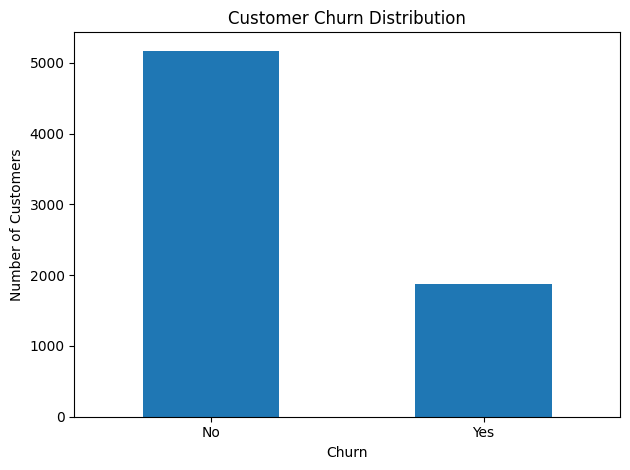

In [14]:
df["Churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

##### Observation

The target variable shows a clear class imbalance. The number of customers who did not churn is substantially higher than the number of customers who churned.

This indicates that the dataset is not evenly distributed across the two target classes. Class imbalance should therefore be considered during model training and evaluation to ensure that the model does not favor the majority class.

#### Data Dictionary

A data dictionary is created to document the meaning, data type, possible values, and potential relevance of each variable for customer churn prediction.

| Feature | Meaning | Type | Possible / Typical Values | ML Relevance |
|---|---|---|---|---|
| CustomerID | Unique identifier assigned to each customer | Identifier | Unique customer ID | Not used as a predictive feature |
| gender | Customer gender | Categorical | Male, Female | Potential customer characteristic |
| SeniorCitizen | Indicates whether the customer is a senior citizen | Binary | 0, 1 | May help identify churn patterns |
| Partner | Whether the customer has a partner | Binary/Categorical | Yes, No | Customer demographic factor |
| Dependents | Whether the customer has dependents | Binary/Categorical | Yes, No | Customer demographic factor |
| tenure | Number of months the customer has stayed with the company | Numerical | Non-negative integer | Important indicator of customer relationship length |
| PhoneService | Whether the customer has phone service | Categorical | Yes, No | Service-related feature |
| MultipleLines | Whether the customer has multiple phone lines | Categorical | Yes, No, No phone service | Service usage characteristic |
| InternetService | Type of internet service | Categorical | DSL, Fiber optic, No | Important service-related feature |
| OnlineSecurity | Whether online security service is enabled | Categorical | Yes, No, No internet service | Service feature potentially associated with churn |
| OnlineBackup | Whether online backup service is enabled | Categorical | Yes, No, No internet service | Service feature |
| DeviceProtection | Whether device protection is enabled | Categorical | Yes, No, No internet service | Service feature |
| TechSupport | Whether technical support is enabled | Categorical | Yes, No, No internet service | Service feature potentially associated with churn |
| StreamingTV | Whether the customer has streaming TV service | Categorical | Yes, No, No internet service | Service usage characteristic |
| StreamingMovies | Whether the customer has streaming movie service | Categorical | Yes, No, No internet service | Service usage characteristic |
| Contract | Customer's contract type | Categorical | Month-to-month, One year, Two year | Important contractual factor |
| PaperlessBilling | Whether the customer uses paperless billing | Categorical | Yes, No | Billing characteristic |
| PaymentMethod | Customer's payment method | Categorical | Electronic check, mailed check, bank transfer, credit card | Payment behavior characteristic |
| MonthlyCharges | Customer's monthly service charge | Numerical | Continuous monetary value | Important billing-related feature |
| TotalCharges | Total amount charged to the customer | Numerical | Continuous monetary value | Important cumulative billing feature |
| Churn | Indicates whether the customer left the company | Target | Yes, No | Prediction target |

#### Feature Groups

For analysis and modeling, the variables can be grouped into the following categories:

**Customer Demographics**
- gender
- SeniorCitizen
- Partner
- Dependents

**Customer Relationship**
- tenure

**Subscribed Services**
- PhoneService
- MultipleLines
- InternetService
- OnlineSecurity
- OnlineBackup
- DeviceProtection
- TechSupport
- StreamingTV
- StreamingMovies

**Contract & Billing**
- Contract
- PaperlessBilling
- PaymentMethod
- MonthlyCharges
- TotalCharges

**Identifier**
- CustomerID

**Target**
- Churn

##### Initial Machine Learning Role

The `Churn` column is the target variable for this supervised learning problem.

`CustomerID` is an identifier and is not expected to provide meaningful predictive information, so it should not be treated as a model feature.

The remaining customer, service, contract, and billing variables will be assessed during preprocessing and exploratory analysis before the final feature set is determined.

#### Data Quality Investigation

In [15]:
# Missing Values
missing_summary = df.isnull().sum().sort_values(ascending=False)

missing_summary[missing_summary > 0]

Series([], dtype: int64)

In [16]:
# Duplicate Records
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

Duplicate rows: 0


In [17]:
# Blank and Whitespace Values
blank_summary = (
    df.select_dtypes(include="object")
      .apply(lambda column: column.astype(str).str.strip().eq("").sum())
      .sort_values(ascending=False)
)

blank_summary[blank_summary > 0]

TotalCharges    11
dtype: int64

In [18]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [19]:
# Unique Values & Category Consistency
categorical_columns = df.select_dtypes(include="object").columns

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].value_counts(dropna=False))


customerID
customerID
3186-AJIEK    1
7590-VHVEG    1
5575-GNVDE    1
8775-CEBBJ    1
2823-LKABH    1
             ..
6713-OKOMC    1
1452-KIOVK    1
9305-CDSKC    1
9237-HQITU    1
7795-CFOCW    1
Name: count, Length: 7043, dtype: int64

gender
gender
Male      3555
Female    3488
Name: count, dtype: int64

Partner
Partner
No     3641
Yes    3402
Name: count, dtype: int64

Dependents
Dependents
No     4933
Yes    2110
Name: count, dtype: int64

PhoneService
PhoneService
Yes    6361
No      682
Name: count, dtype: int64

MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64

InternetService
InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

OnlineSecurity
OnlineSecurity
No                     3498
Yes                    2019
No internet service    1526
Name: count, dtype: int64

OnlineBackup
OnlineBackup
No                     3088
Yes                    2429


In [20]:
# Numerical Range Check
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.0,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [21]:
# Identifier Assessment
print("CustomerID unique values:", df["customerID"].nunique())
print("Total rows:", len(df))

CustomerID unique values: 7043
Total rows: 7043


In [22]:
# Target Integrity
print(df["Churn"].value_counts(dropna=False))
print("\nUnique target values:")
print(df["Churn"].unique())

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Unique target values:
['No' 'Yes']


In [23]:
# Potential Data Leakage Assessment
print(df.columns.tolist())

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


#### Data Quality Summary

In [24]:
quality_summary = pd.DataFrame({
    "Check": [
        "Rows",
        "Columns",
        "Missing cells",
        "Duplicate rows",
        "Target missing values"
    ],
    "Result": [
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        df["Churn"].isnull().sum()
    ]
})

quality_summary

,Check,Result
0,Rows,7043
1,Columns,21
2,Missing cells,0
3,Duplicate rows,0
4,Target missing values,0


#### Data Quality Assessment — Analysis

The initial data-quality assessment shows that the dataset contains **7,043 customer records and 21 variables**. No completely missing columns or duplicate records were identified.

- **Missing values:** The standard missing-value check returned no `NaN` values. However, **`TotalCharges` contains 11 blank values**, which are not detected as standard missing values and require treatment during preprocessing.
- **Duplicate records:** **0 duplicate rows** were identified.
- **Identifier:** `customerID` contains **7,043 unique values for 7,043 records**, confirming that it functions as a unique customer identifier and should not be used as a predictive feature.
- **Data types:** `TotalCharges` is currently stored as `object` even though it represents a numerical billing amount. It will therefore require conversion to a numeric data type after addressing the blank values.
- **Categorical variables:** The inspected categorical variables contain consistent, expected categories such as `Yes/No`, service types, contract types, and payment methods. No obvious unexpected categories were identified during the initial inspection.
- **Target variable:** `Churn` contains only the expected classes, `Yes` and `No`, with **5,174 customers who did not churn and 1,869 customers who churned**.
- **Class distribution:** The target is imbalanced, with the non-churned class representing the majority of records. This should be considered during model training and evaluation.

#### Conclusion

The dataset is generally well structured, but **`TotalCharges` requires cleaning and numeric conversion**, and the **class imbalance in `Churn` should be considered during model development**. The identifier `customerID` will be excluded from predictive features. These findings will guide the data-cleaning and preprocessing stage.

### Data Preparation

#### Handle Data Quality Issues

In [25]:
# Clean Working Dataset
df_clean = df.copy()

> The original raw dataset will remain unchanged. A separate working copy is created so that cleaning and preprocessing can be performed safely and reproducibly.

In [26]:
# Convert TotalCharges to Numeric
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

df_clean["TotalCharges"].dtype

dtype('float64')

In [27]:
# Recheck TotalCharges Missing Values
df_clean["TotalCharges"].isna().sum()

np.int64(11)

In [28]:
# Investigate Missing TotalCharges Records
df_clean[df_clean["TotalCharges"].isna()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


> The affected records are inspected to understand whether the missing `TotalCharges` values follow a recognizable pattern that can guide the cleaning decision.

In [29]:
df_clean.loc[df_clean["TotalCharges"].isna(), ["customerID", "tenure", "MonthlyCharges", "Contract", "Churn"]]

,customerID,tenure,MonthlyCharges,Contract,Churn
488,4472-LVYGI,0,52.55,Two year,No
753,3115-CZMZD,0,20.25,Two year,No
936,5709-LVOEQ,0,80.85,Two year,No
1082,4367-NUYAO,0,25.75,Two year,No
1340,1371-DWPAZ,0,56.05,Two year,No
3331,7644-OMVMY,0,19.85,Two year,No
3826,3213-VVOLG,0,25.35,Two year,No
4380,2520-SGTTA,0,20.00,Two year,No
5218,2923-ARZLG,0,19.70,One year,No
6670,4075-WKNIU,0,73.35,Two year,No


##### Missing `TotalCharges` — Cleaning Decision

The 11 records with missing `TotalCharges` values all have a `tenure` of 0 months. These records represent customers at the beginning of their relationship with the company, and their `MonthlyCharges` values are already available.

Because `TotalCharges` represents accumulated charges, the missing values will be treated as **0** for these zero-tenure customers.

The records will be retained because they represent valid customer observations rather than duplicate or invalid records.

In [30]:
df_clean.loc[df_clean["tenure"] == 0, "TotalCharges"] = (df_clean.loc[df_clean["tenure"] == 0, "TotalCharges"].fillna(0))

In [31]:
df_clean["TotalCharges"].isna().sum()

np.int64(0)

#### Define Features & Target

In [32]:
# Define the Target Variable
y = df_clean["Churn"]
y.head()

0     No
1     No
2    Yes
3     No
4    Yes
Name: Churn, dtype: object

In [33]:
# Define Predictor Features
X = df_clean.drop(columns=["Churn", "customerID"])
X.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


> All available customer, service, contract, and billing variables will initially be considered as potential predictors.

> The `customerID` column will be excluded because it uniquely identifies each customer but does not provide meaningful behavioral information for churn prediction.

In [34]:
# Identify Numerical Features
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_features

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

> Numerical features are identified because they will require different preprocessing from categorical variables.

In [35]:
# Identify Categorical Features
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_features

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

> Categorical features contain labels or categories rather than continuous numerical values. These variables will require categorical encoding before being used by the machine learning models.

In [36]:
# Verify Feature Groups
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal features:", len(X.columns))

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Total features: 19


In [37]:
# Feature and Target Verification
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget classes:")
print(y.value_counts())

X shape: (7043, 19)
y shape: (7043,)

Target classes:
Churn
No     5174
Yes    1869
Name: count, dtype: int64


The feature matrix `X` contains the variables used to make predictions, while `y` contains the historical churn outcomes used for supervised learning.

#### Encode the Target

In [38]:
# Encode the Target Variable
y_encoded = y.map({"No": 0, "Yes": 1})
y_encoded.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

- `Yes` → `1`
- `No` → `0`

In [39]:
# Verify Target Encoding
print("Unique encoded values:", y_encoded.unique())

Unique encoded values: [0 1]


In [40]:
# Check for Missing Encoded Values
print("Missing encoded target values:", y_encoded.isna().sum())

Missing encoded target values: 0


In [41]:
# Encoded Class Distribution
class_distribution = y_encoded.value_counts().sort_index()

print(f"Non-Churn (0): {class_distribution.get(0, 0):,}")
print(f"Churn (1): {class_distribution.get(1, 0):,}")

Non-Churn (0): 5,174
Churn (1): 1,869


In [42]:
class_percentage = (y_encoded.value_counts(normalize=True).sort_index().mul(100).round(2))

print(f"Non-Churn (0): {class_percentage.get(0, 0):.2f}%")
print(f"Churn (1): {class_percentage.get(1, 0):.2f}%")

Non-Churn (0): 73.46%
Churn (1): 26.54%


##### Observation

The encoded target shows a noticeable class imbalance:

- **Non-Churn (0): 73.46%**
- **Churn (1): 26.54%**

Approximately one quarter of the customers in the dataset churned, while the majority remained with the company. This imbalance should be considered during model training and evaluation so that model performance is not judged by accuracy alone.

In [43]:
# Replace Original Target Variable
y = y_encoded

In [44]:
# Final Check
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


#### Build Feature Preprocessing

The predictor variables consist of numerical and categorical features.

**Numerical features** will be handled separately from categorical features.

**Categorical features** will be transformed into numerical representations so they can be used by machine learning models.

Preprocessing transformations will be fitted only on the training data and then applied to validation, test, and future customer data to avoid data leakage.

In [45]:
# Numerical Feature Preprocessing
numeric_transformer = StandardScaler()

> Numerical features such as `tenure`, `MonthlyCharges`, and `TotalCharges` have different value ranges.

> Standardization will be applied using `StandardScaler` so that numerical features are centered around zero with a standard deviation of one.

In [46]:
# Categorical Feature Preprocessing
categorical_transformer = OneHotEncoder(handle_unknown="ignore")

> Categorical variables cannot be used directly by most of the selected machine learning models.

> One-hot encoding will be used to convert categorical values into numerical indicator features.

In [47]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

A `ColumnTransformer` is used to apply the appropriate transformation to each feature group.

- Numerical features → StandardScaler
- Categorical features → OneHotEncoder

> This creates a single reproducible preprocessing object that can later be connected directly to the machine learning model.

In [48]:
# Verify Preprocessor
print(preprocessor)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])


#### Train / Validation / Test Split

We will divide the dataset into **three separate subsets** so model development and final evaluation remain reliable.

Split strategy

- Training: 70% — model training and preprocessing fitting
- Validation: 15% — model comparison and tuning
- Test: 15% — final unbiased evaluation

Because Churn is imbalanced, stratification is used to preserve approximately the same churn/non-churn proportion in all three subsets.

In [49]:
# Create Training and Temporary Sets
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)

- 70% of the data will be used for training.
- 30% will later be divided equally into validation and test sets.

In [50]:
# Create Validation and Test Sets
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

> The temporary 30% subset is split equally into validation and test sets.

In [51]:
# Verify Dataset Sizes
print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (4930, 19)
Validation set: (1056, 19)
Test set: (1057, 19)


In [52]:
# Verify Class Distribution
print("Training:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nValidation:")
print(y_val.value_counts(normalize=True).mul(100).round(2))

print("\nTest:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training:
Churn
0    73.47
1    26.53
Name: proportion, dtype: float64

Validation:
Churn
0    73.48
1    26.52
Name: proportion, dtype: float64

Test:
Churn
0    73.42
1    26.58
Name: proportion, dtype: float64


##### Split Observation

The dataset has been divided into training, validation, and test sets using stratified sampling.

The similar class proportions across the three subsets indicate that the `Churn` imbalance has been preserved during the split.

The test set will remain isolated and will only be used for final evaluation after model selection and optimization.

#### Build Reproducible Preprocessing Pipeline

In [53]:
# Fit Preprocessor on Training Data
X_train_processed = preprocessor.fit_transform(X_train)

> Fitting only on training data prevents information from the validation and test sets from influencing the preprocessing stage.

In [54]:
# Transform Validation and Test Data
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

> The fitted preprocessing pipeline is applied to the validation and test datasets using the same transformations learned from the training data.

> The preprocessor is not fitted again on these datasets.

In [55]:
# Check Transformed Shapes

print("Training:", X_train_processed.shape)
print("Validation:", X_val_processed.shape)
print("Test:", X_test_processed.shape)

Training: (4930, 45)
Validation: (1056, 45)
Test: (1057, 45)


In [56]:
# Verify No Missing Values

print("Training missing values:", np.isnan(X_train_processed).sum())
print("Validation missing values:", np.isnan(X_val_processed).sum())
print("Test missing values:", np.isnan(X_test_processed).sum())

Training missing values: 0
Validation missing values: 0
Test missing values: 0


##### Save the Fitted Preprocessing Pipeline

The fitted preprocessing object will be saved as a reusable artifact. This allows future customer records to pass through the exact same transformations used during model development.

In [57]:
model_path = Path("../models")
model_path.mkdir(parents=True, exist_ok=True)

joblib.dump(preprocessor, model_path / "preprocessing_pipeline.joblib")

print("Preprocessing pipeline saved successfully.")

Preprocessing pipeline saved successfully.


#### Preparation Validation

In [58]:
# Validate Feature Dimensions
print("Training features:", X_train_processed.shape[1])
print("Validation features:", X_val_processed.shape[1])
print("Test features:", X_test_processed.shape[1])

Training features: 45
Validation features: 45
Test features: 45


In [59]:
assert X_train_processed.shape[1] == X_val_processed.shape[1] == X_test_processed.shape[1]

print("Feature dimensions are consistent.")

Feature dimensions are consistent.


In [60]:
# Missing Value Validation
print("Training missing values:", np.isnan(X_train_processed).sum())
print("Validation missing values:", np.isnan(X_val_processed).sum())
print("Test missing values:", np.isnan(X_test_processed).sum())

Training missing values: 0
Validation missing values: 0
Test missing values: 0


In [61]:
assert np.isnan(X_train_processed).sum() == 0
assert np.isnan(X_val_processed).sum() == 0
assert np.isnan(X_test_processed).sum() == 0

print("No missing values remain in the transformed features.")

No missing values remain in the transformed features.


In [62]:
# Numerical Feature Validation
print("Training dtype:", X_train_processed.dtype)
print("Validation dtype:", X_val_processed.dtype)
print("Test dtype:", X_test_processed.dtype)

Training dtype: float64
Validation dtype: float64
Test dtype: float64


In [63]:
assert np.issubdtype(X_train_processed.dtype, np.number)
assert np.issubdtype(X_val_processed.dtype, np.number)
assert np.issubdtype(X_test_processed.dtype, np.number)

print("All transformed features are numerical.")

All transformed features are numerical.


In [64]:
# Dataset Separation Validation
print("Training records:", len(X_train))
print("Validation records:", len(X_val))
print("Test records:", len(X_test))
print("Total records:", len(X_train) + len(X_val) + len(X_test))

Training records: 4930
Validation records: 1056
Test records: 1057
Total records: 7043


In [65]:
assert len(X_train) + len(X_val) + len(X_test) == len(df_clean)

print("Train/validation/test separation is confirmed.")

Train/validation/test separation is confirmed.


##### Preparation Validation — Summary

The dataset is now prepared for machine learning model development.

- Numerical and categorical features have been processed using the defined preprocessing pipeline.
- The preprocessing pipeline was fitted only on the training data.
- Training, validation, and test sets contain consistent feature dimensions.
- No missing values remain in the transformed feature matrices.
- All transformed inputs are numerical and suitable for machine learning models.
- The test set remains isolated for final evaluation.

The prepared data can now be used for model development and comparison.

### EDA & Business Analysis

#### Overall Churn Analysis

In [66]:
# Overall Churn Distribution
churn_counts = y.value_counts().sort_index()

print("Non-Churn (0):", churn_counts[0])
print("Churn (1):", churn_counts[1])

Non-Churn (0): 5174
Churn (1): 1869


In [67]:
# Churn Rate
churn_rate = y.mean() * 100

print(f"Overall churn rate: {churn_rate:.2f}%")

Overall churn rate: 26.54%


In [68]:
# Compare Churned vs Non-Churned Customers
churn_summary = pd.DataFrame({
    "Churn Status": ["Did Not Churn", "Churned"],
    "Customers": [churn_counts[0], churn_counts[1]],
    "Percentage": [
        (churn_counts[0] / len(y)) * 100,
        (churn_counts[1] / len(y)) * 100
    ]
})

churn_summary["Percentage"] = churn_summary["Percentage"].round(2)

churn_summary

,Churn Status,Customers,Percentage
0,Did Not Churn,5174,73.46
1,Churned,1869,26.54


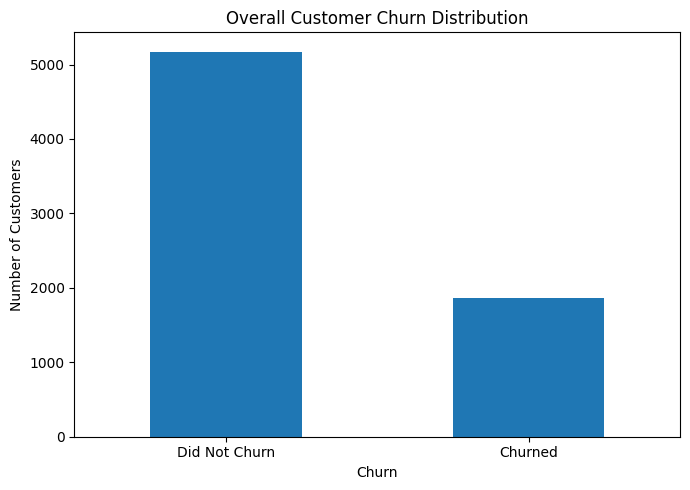

In [69]:
# Visualize Churn Rate
churn_counts.plot(kind="bar", figsize=(7, 5))

plt.title("Overall Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(
    ticks=[0, 1],
    labels=["Did Not Churn", "Churned"],
    rotation=0
)

plt.tight_layout()
plt.show()

##### Churn Analysis — Key Findings

The dataset contains a higher proportion of customers who did not churn than customers who churned.

The overall churn rate is **26.54%%**, meaning that approximately one out of every four customers in the dataset has a historical churn outcome of `Yes`.

This provides an important baseline for the subsequent analysis.

#### Customer Demographic Analysis

In [70]:
# Churn by Gender
gender_churn = pd.crosstab(df_clean["gender"], df_clean["Churn"], normalize="index").mul(100).round(2)

gender_churn

Churn,No,Yes
gender,,
Female,73.08,26.92
Male,73.84,26.16


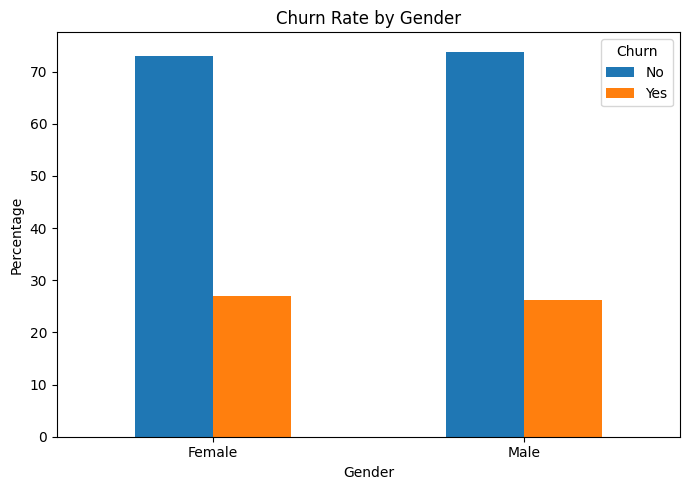

In [71]:
gender_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

> Churn rates are very similar across genders, with females at approximately **27%** and males at approximately **26%**. Gender therefore shows little practical difference in churn within this dataset.

In [72]:
# Churn by Senior Citizen Status
senior_churn = pd.crosstab(df_clean["SeniorCitizen"], df_clean["Churn"], normalize="index").mul(100).round(2)

senior_churn.index = ["Non-Senior", "Senior"]

senior_churn

Churn,No,Yes
Non-Senior,76.39,23.61
Senior,58.32,41.68


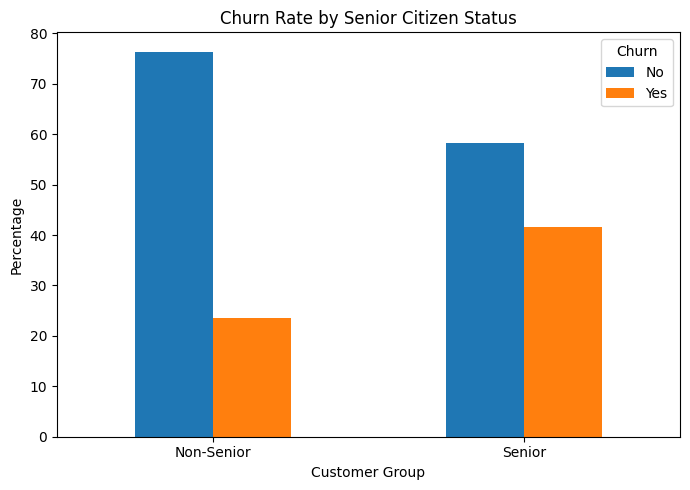

In [73]:
senior_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Customer Group")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

> Senior customers show a substantially higher churn rate (**~42%**) than non-senior customers (**~24%**). This indicates that senior-citizen status is a potentially important variable for further churn analysis.

In [74]:
# Churn by Partner Status
partner_churn = pd.crosstab(df_clean["Partner"], df_clean["Churn"], normalize="index").mul(100).round(2)

partner_churn

Churn,No,Yes
Partner,,
No,67.04,32.96
Yes,80.34,19.66


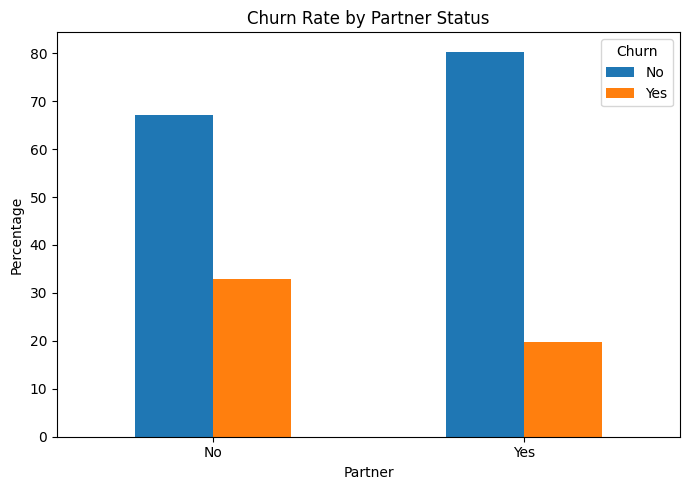

In [75]:
partner_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Churn Rate by Partner Status")
plt.xlabel("Partner")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

> Customers without a partner have a higher churn rate (**~33%**) than customers with a partner (**~20%**). This suggests a meaningful difference in churn patterns that should be examined alongside other customer characteristics.

In [76]:
# Churn by Dependents
dependents_churn = pd.crosstab(df_clean["Dependents"], df_clean["Churn"], normalize="index").mul(100).round(2)

dependents_churn

Churn,No,Yes
Dependents,,
No,68.72,31.28
Yes,84.55,15.45


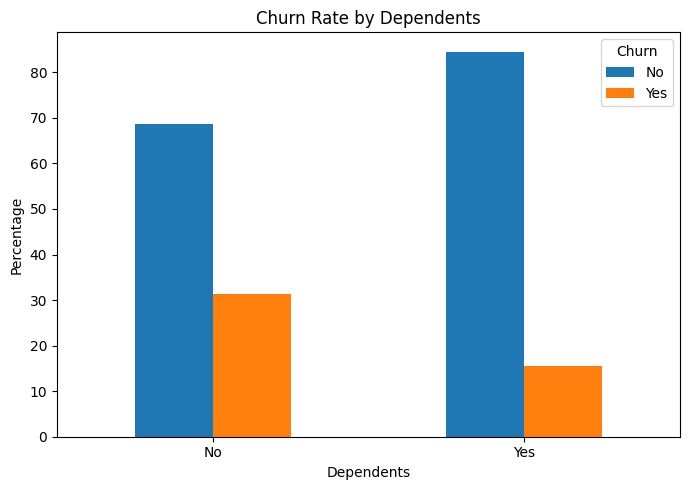

In [77]:
dependents_churn.plot(kind="bar", figsize=(7, 5))

plt.title("Churn Rate by Dependents")
plt.xlabel("Dependents")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

> Customers without dependents show a considerably higher churn rate (**~31%**) than customers with dependents (**~16%**). Dependents therefore appear to be an important characteristic for further investigation.

##### Demographic Analysis — Key Findings

The demographic analysis shows that **gender has little difference in observed churn**, while **senior-citizen status, partner status, and dependent status show more substantial differences**.

These observations identify potentially useful predictors for subsequent analysis, but they represent associations within the dataset rather than evidence that these characteristics directly cause customer churn.

In [78]:
demographic_summary = pd.DataFrame({
    "Demographic": ["Female", "Male", "Non-Senior", "Senior", "No Partner", "Partner", "No Dependents", "Dependents"],
    "Churn Rate (%)": [
        gender_churn.loc["Female", "Yes"],
        gender_churn.loc["Male", "Yes"],
        senior_churn.loc["Non-Senior", "Yes"],
        senior_churn.loc["Senior", "Yes"],
        partner_churn.loc["No", "Yes"],
        partner_churn.loc["Yes", "Yes"],
        dependents_churn.loc["No", "Yes"],
        dependents_churn.loc["Yes", "Yes"]
    ]
})

demographic_summary

,Demographic,Churn Rate (%)
0,Female,26.92
1,Male,26.16
2,Non-Senior,23.61
3,Senior,41.68
4,No Partner,32.96
5,Partner,19.66
6,No Dependents,31.28
7,Dependents,15.45


#### Tenure & Customer Relationship Analysis

In [79]:
# Churn by Tenure
tenure_churn_summary = (df_clean.groupby("Churn")["tenure"].agg(["mean", "median", "min", "max"]).round(2))

tenure_churn_summary

,mean,median,min,max
Churn,,,,
No,37.57,38.0,0,72
Yes,17.98,10.0,1,72


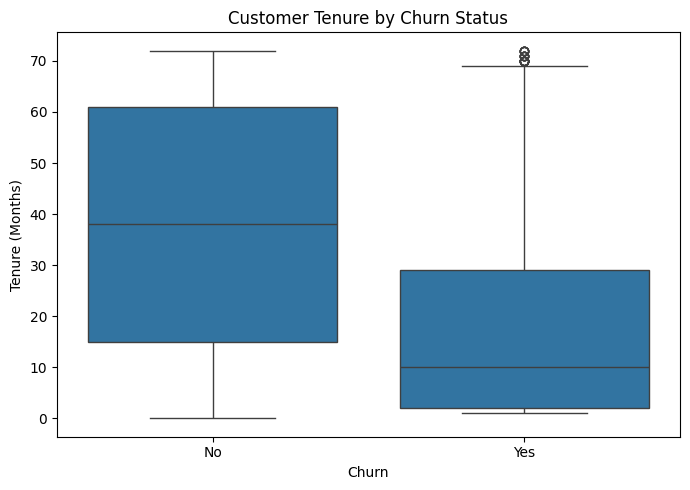

In [80]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df_clean, x="Churn", y="tenure")

plt.title("Customer Tenure by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.show()

> Churned customers have substantially lower tenure than non-churned customers, with the median tenure around **10 months versus 38 months**. This indicates that customers earlier in their relationship with the company show considerably higher observed churn.

In [81]:
# Tenure Groups
tenure_bins = [0, 12, 24, 48, 72]
tenure_labels = ["0-12 months", "13-24 months", "25-48 months", "49-72 months"]

df_clean["tenure_group"] = pd.cut(df_clean["tenure"], bins=tenure_bins, labels=tenure_labels, include_lowest=True)

df_clean["tenure_group"].value_counts().sort_index()

tenure_group
0-12 months     2186
13-24 months    1024
25-48 months    1594
49-72 months    2239
Name: count, dtype: int64

In [82]:
# Churn Rate by Tenure Group
tenure_churn = (pd.crosstab(df_clean["tenure_group"], df_clean["Churn"], normalize="index").mul(100).round(2))

tenure_churn

Churn,No,Yes
tenure_group,,
0-12 months,52.56,47.44
13-24 months,71.29,28.71
25-48 months,79.61,20.39
49-72 months,90.49,9.51


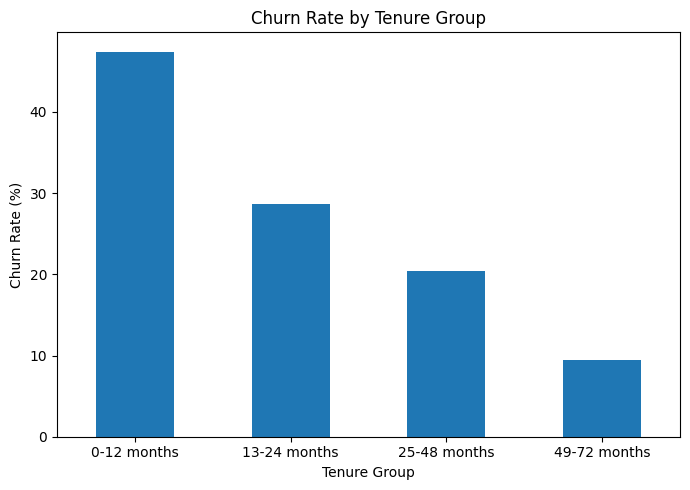

In [83]:
tenure_churn["Yes"].plot(kind="bar", figsize=(7, 5))

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> Churn decreases consistently as customer tenure increases, falling from **47.44% for customers with 0–12 months** of tenure to **9.51% for customers with 49–72 months**. This shows a strong association between shorter customer relationships and higher churn.

In [84]:
# New vs. Long-Term Customers
new_vs_long_term = tenure_churn.loc[["0-12 months", "49-72 months"], "Yes"]

new_vs_long_term

tenure_group
0-12 months     47.44
49-72 months     9.51
Name: Yes, dtype: float64

> Newer customers (0–12 months) have a churn rate of **47.44%**, compared with only **9.51%** among customers with 49–72 months of tenure. The large difference highlights early customer lifecycle as an important area for retention analysis.

##### Tenure Analysis — Key Findings

Customer tenure shows a strong relationship with observed churn. Churn is substantially higher among newer customers and declines consistently as the customer relationship becomes longer.

The results suggest that **early-stage customers may represent a high-priority group for retention efforts**, while tenure should be considered an important predictor during model development.

#### Service Usage Analysis

In [85]:
# Churn by Phone Service
phone_churn = (pd.crosstab(df_clean["PhoneService"], df_clean["Churn"], normalize="index").mul(100).round(2))

phone_churn

Churn,No,Yes
PhoneService,,
No,75.07,24.93
Yes,73.29,26.71


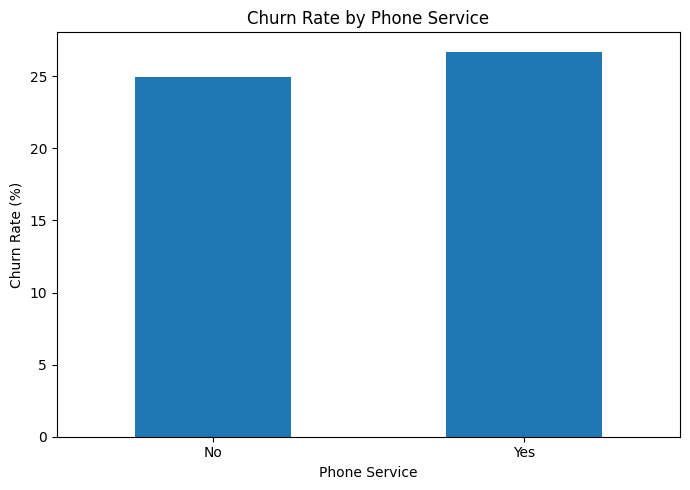

In [86]:
phone_churn["Yes"].plot(kind="bar", figsize=(7, 5))

plt.title("Churn Rate by Phone Service")
plt.xlabel("Phone Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> Churn rates are very similar for customers with and without phone service, at approximately **26.7%** and **24.9%**, respectively. Phone service therefore shows relatively little difference in observed churn.

In [87]:
# Churn by Internet Service
internet_churn = (pd.crosstab(df_clean["InternetService"], df_clean["Churn"], normalize="index").mul(100).round(2))

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


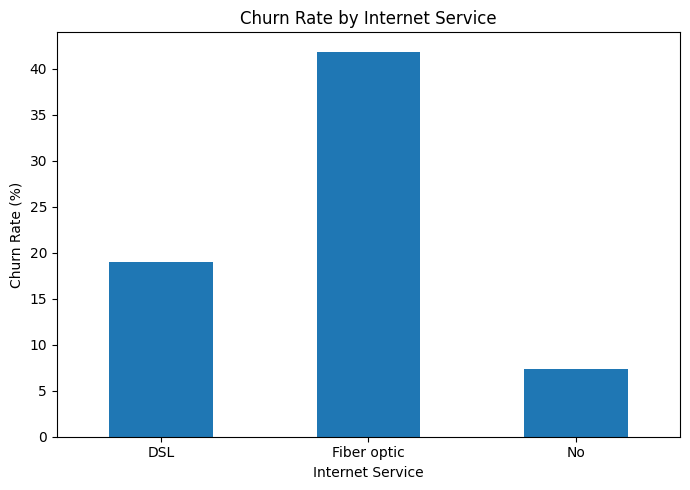

In [88]:
internet_churn["Yes"].plot(kind="bar", figsize=(7, 5))

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> Churn differs substantially by internet service, with **Fiber optic customers showing the highest churn (~41.9%)**, compared with **18.9% for DSL** and **7.4% for customers without internet service**. Internet service type appears to be an important churn-related feature.

In [89]:
# Churn Across Security and Support Services
security_support_features = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]

security_support_churn = {}

for column in security_support_features:
    security_support_churn[column] = pd.crosstab(df_clean[column], df_clean["Churn"], normalize="index").mul(100).round(2)

security_support_churn

{'OnlineSecurity': Churn                   No    Yes
 OnlineSecurity                   
 No                   58.23  41.77
 No internet service  92.60   7.40
 Yes                  85.39  14.61,
 'OnlineBackup': Churn                   No    Yes
 OnlineBackup                     
 No                   60.07  39.93
 No internet service  92.60   7.40
 Yes                  78.47  21.53,
 'DeviceProtection': Churn                   No    Yes
 DeviceProtection                 
 No                   60.87  39.13
 No internet service  92.60   7.40
 Yes                  77.50  22.50,
 'TechSupport': Churn                   No    Yes
 TechSupport                      
 No                   58.36  41.64
 No internet service  92.60   7.40
 Yes                  84.83  15.17}

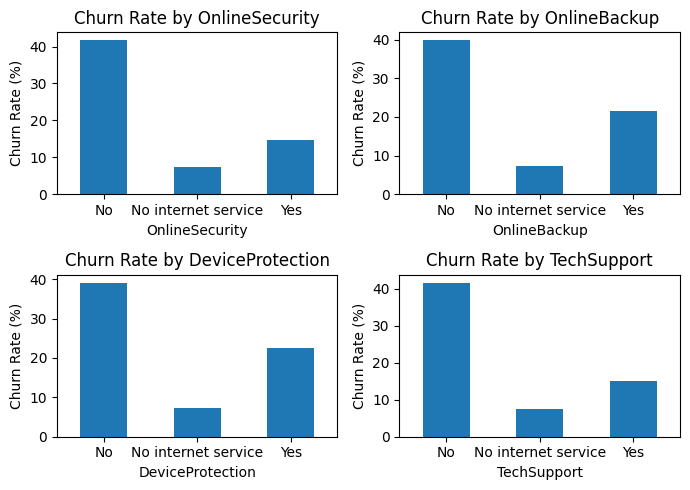

In [90]:
fig, axes = plt.subplots(2, 2,figsize=(7, 5))

for ax, column in zip(axes.flat, security_support_features):
    churn_rates = security_support_churn[column]["Yes"]
    churn_rates.plot(kind="bar",ax=ax)

    ax.set_title(f"Churn Rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

> Customers without online security show a much higher churn rate (**~41.8%**) than customers with the service (**~14.7%**).

> Customers without online backup have a higher churn rate (**~40%**) than those with the service (**~21.5%**).

> Customers without device protection show considerably higher churn (**~39%**) than customers with device protection (**~22%**).

> Customers without tech support have a substantially higher churn rate (**~41%**) than customers with tech support (**~15%**).

> These factors appears to be noticeable difference for learning. 

> These variables show noticeable differences in observed churn rates and are therefore strong candidates for further modeling.

In [91]:
# Churn Across Streaming Services
streaming_features = ["StreamingTV", "StreamingMovies"]

streaming_churn = {}

for column in streaming_features:
    streaming_churn[column] = pd.crosstab( df_clean[column], df_clean["Churn"], normalize="index" ).mul(100).round(2)

streaming_churn

{'StreamingTV': Churn                   No    Yes
 StreamingTV                      
 No                   66.48  33.52
 No internet service  92.60   7.40
 Yes                  69.93  30.07,
 'StreamingMovies': Churn                   No    Yes
 StreamingMovies                  
 No                   66.32  33.68
 No internet service  92.60   7.40
 Yes                  70.06  29.94}

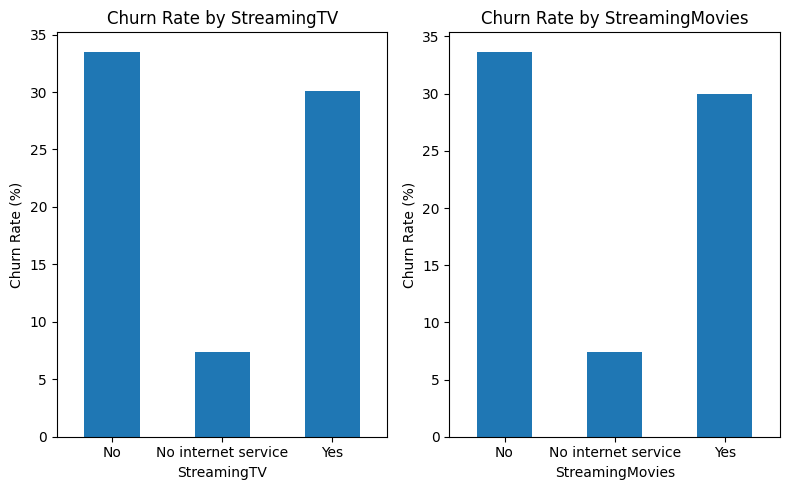

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(8, 5))

for ax, column in zip(axes, streaming_features):
    streaming_churn[column]["Yes"].plot(kind="bar",ax=ax)

    ax.set_title(f"Churn Rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Churn Rate (%)")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

> Churn rates are relatively close for customers with and without Streaming TV, at approximately **30.0%** and **33.5%**, respectively.

> Customers without Streaming Movies show a churn rate of approximately **33.5%**, compared with **30.0%** for customers with the service.

> Streaming TV/Movies shows a smaller difference than several security and support services.

In [93]:
# Internet Service and Tech Support
internet_support_churn = df_clean.groupby(["InternetService", "TechSupport"])["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2).reset_index(name="Churn Rate (%)")

internet_support_churn

,InternetService,TechSupport,Churn Rate (%)
0,DSL,No,27.76
1,DSL,Yes,9.68
2,Fiber optic,No,49.37
3,Fiber optic,Yes,22.63
4,No,No internet service,7.40


> The combination of internet service and tech support reveals substantial differences in churn. **Fiber optic customers without tech support have the highest observed churn at 49.37%**, compared with **22.63% for those with tech support**.

In [94]:
# Contract and Internet Service
contract_internet_churn = df_clean.groupby(["Contract", "InternetService"])["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2).reset_index(name="Churn Rate (%)")

contract_internet_churn

,Contract,InternetService,Churn Rate (%)
0,Month-to-month,DSL,32.22
1,Month-to-month,Fiber optic,54.61
2,Month-to-month,No,18.89
3,One year,DSL,9.30
4,One year,Fiber optic,19.29
5,One year,No,2.47
6,Two year,DSL,1.91
7,Two year,Fiber optic,7.23
8,Two year,No,0.78


> Churn is highest among **month-to-month Fiber optic customers (54.61%)**, while long-term contracts show dramatically lower churn across internet-service types. The combination of contract length and internet service appears highly relevant to churn behavior.

##### Service Usage Analysis — Key Findings

Service-related variables show substantially different churn patterns. **Internet service type, online security, online backup, device protection, and tech support** display notable differences, while phone service and streaming services show comparatively smaller differences.

The strongest observed patterns occur when service characteristics are considered together, particularly **internet service + tech support** and **contract + internet service**. These relationships will be considered during model development while being treated as associations rather than causal effects.

#### Contract & Billing Analysis

In [95]:
# Churn by Contract Type
contract_churn = pd.crosstab(df_clean["Contract"], df_clean["Churn"], normalize="index").mul(100).round(2)

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


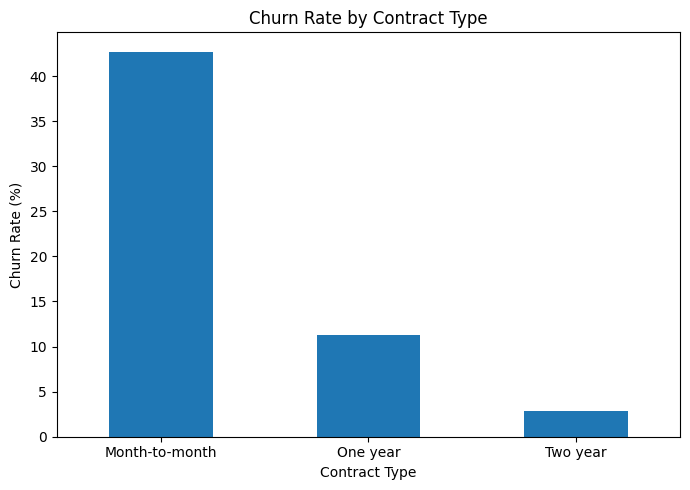

In [96]:
contract_churn["Yes"].plot(kind="bar", figsize=(7, 5))

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> Contract type shows one of the strongest churn differences: **month-to-month customers have ~42.7% churn**, compared with **~11.2% for one-year** and **~2.8% for two-year contracts**. Longer-term contracts are strongly associated with lower observed churn.

In [97]:
# Churn by Payment Method
payment_churn = pd.crosstab(df_clean["PaymentMethod"], df_clean["Churn"], normalize="index").mul(100).round(2)

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


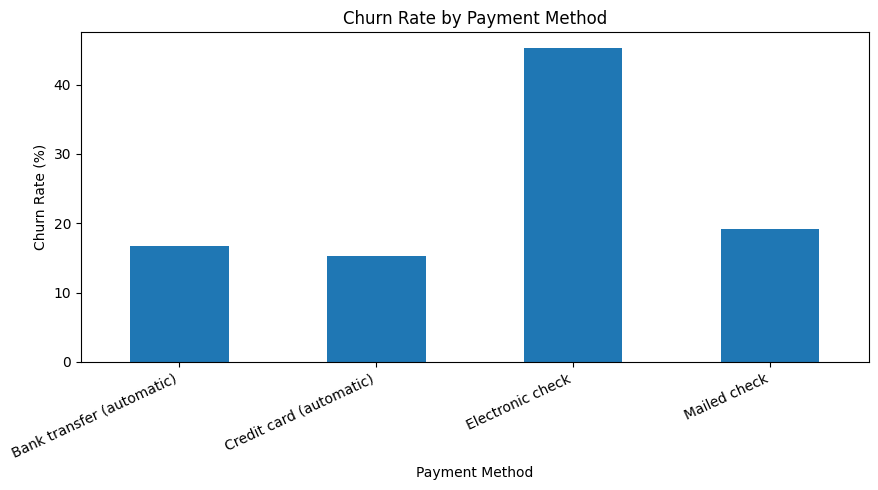

In [98]:
payment_churn["Yes"].plot(kind="bar", figsize=(9, 5))

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

> **Electronic check users have the highest churn rate (~45%)**, substantially above automatic bank transfer (~16.7%), credit card (~15.2%), and mailed check (~19.1%). Payment method therefore shows a notable difference in churn behavior.

In [99]:
# Churn by Paperless Billing
paperless_churn = pd.crosstab(df_clean["PaperlessBilling"], df_clean["Churn"], normalize="index").mul(100).round(2)

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,83.67,16.33
Yes,66.43,33.57


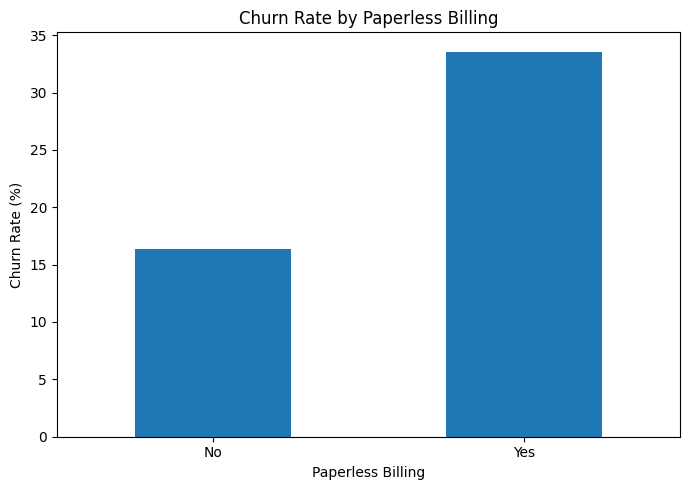

In [100]:
paperless_churn["Yes"].plot(kind="bar", figsize=(7, 5))

plt.title("Churn Rate by Paperless Billing")
plt.xlabel("Paperless Billing")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> Customers using **paperless billing have a higher churn rate (~33.6%)** than customers using non-paperless billing (~16.6%). This noticeable difference makes billing preference a relevant candidate for further modeling.

In [101]:
# Monthly Charges and Churn
monthly_charges_summary = df_clean.groupby("Churn")["MonthlyCharges"].agg(["mean", "median", "min", "max"]).round(2)

monthly_charges_summary

,mean,median,min,max
Churn,,,,
No,61.27,64.43,18.25,118.75
Yes,74.44,79.65,18.85,118.35


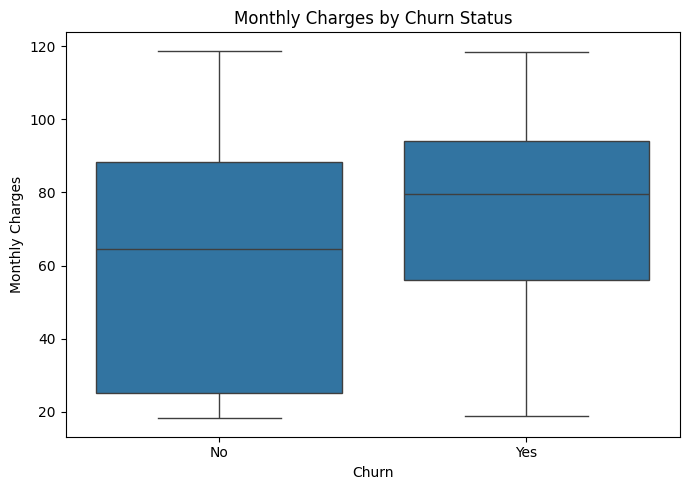

In [102]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df_clean, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.tight_layout()
plt.show()

> Churned customers have higher monthly charges on average (**$74.44**) than non-churned customers (**$61.27**). The distribution also indicates that churn is more common among customers with higher recurring charges.

In [103]:
# Total Charges and Churn
total_charges_summary = df_clean.groupby("Churn")["TotalCharges"].agg(["mean", "median", "min", "max"]).round(2)

total_charges_summary

,mean,median,min,max
Churn,,,,
No,2549.91,1679.52,0.00,8672.45
Yes,1531.80,703.55,18.85,8684.80


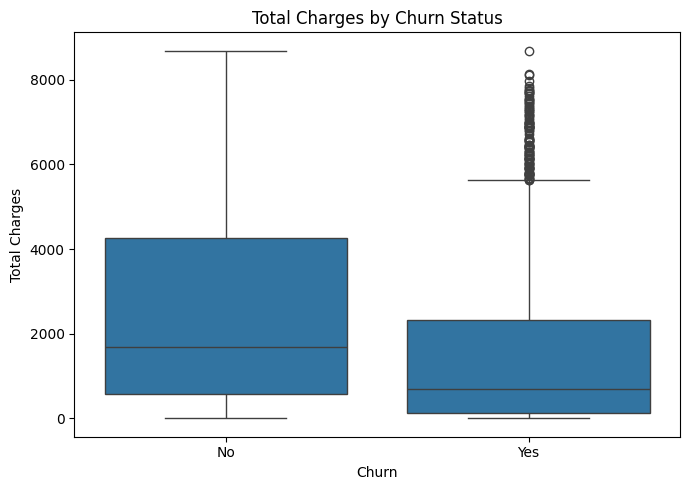

In [104]:
plt.figure(figsize=(7, 5))

sns.boxplot(data=df_clean, x="Churn", y="TotalCharges")

plt.title("Total Charges by Churn Status")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.tight_layout()
plt.show()

> Non-churned customers have substantially higher total charges overall, while churned customers show much lower typical cumulative charges. This pattern is consistent with the strong relationship between **customer tenure and total accumulated charges**.

In [105]:
# Contract and Payment Method
contract_payment_churn = df_clean.groupby(["Contract", "PaymentMethod"])["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2).reset_index(name="Churn Rate (%)")

contract_payment_churn

,Contract,PaymentMethod,Churn Rate (%)
0,Month-to-month,Bank transfer (automatic),34.13
1,Month-to-month,Credit card (automatic),32.78
2,Month-to-month,Electronic check,53.73
3,Month-to-month,Mailed check,31.58
4,One year,Bank transfer (automatic),9.72
5,One year,Credit card (automatic),10.30
6,One year,Electronic check,18.44
7,One year,Mailed check,6.82
8,Two year,Bank transfer (automatic),3.37
9,Two year,Credit card (automatic),2.24


> The combination reveals particularly high churn among **month-to-month customers using electronic checks (53.73%)**, while long-term contract/payment combinations generally show much lower churn. This interaction appears highly informative for churn modeling.

In [106]:
# Contract and Monthly Charges
contract_charge_summary = df_clean.groupby(["Contract", "Churn"])["MonthlyCharges"].mean().round(2).reset_index()

contract_charge_summary

,Contract,Churn,MonthlyCharges
0,Month-to-month,No,61.46
1,Month-to-month,Yes,73.02
2,One year,No,62.51
3,One year,Yes,85.05
4,Two year,No,60.01
5,Two year,Yes,86.78


> Across all contract types, churned customers have higher average monthly charges than non-churned customers, with the largest difference among **two-year customers ($86.78 vs. $60.01)**. Contract and recurring charges therefore provide complementary churn signals.

##### Contract & Billing Analysis — Key Findings

**Contract type shows the strongest churn difference**, followed by payment method and paperless billing. Monthly charges also differ meaningfully between churned and non-churned customers, while total charges are closely connected to customer tenure.

The combined analysis shows that **contract, payment method, and billing characteristics can reveal substantially different customer risk profiles**, making them important candidates for subsequent machine learning.

#### Multivariate / Relationship Analysis

In [107]:
# Tenure and Contract
tenure_contract_churn = df_clean.groupby(["tenure_group", "Contract"], observed=False)["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2).reset_index(name="Churn Rate (%)")

tenure_contract_churn

,tenure_group,Contract,Churn Rate (%)
0,0-12 months,Month-to-month,51.35
1,0-12 months,One year,10.48
2,0-12 months,Two year,0.00
3,13-24 months,Month-to-month,37.72
4,13-24 months,One year,8.12
5,13-24 months,Two year,0.00
6,25-48 months,Month-to-month,32.92
7,25-48 months,One year,10.62
8,25-48 months,Two year,2.19
9,49-72 months,Month-to-month,26.02


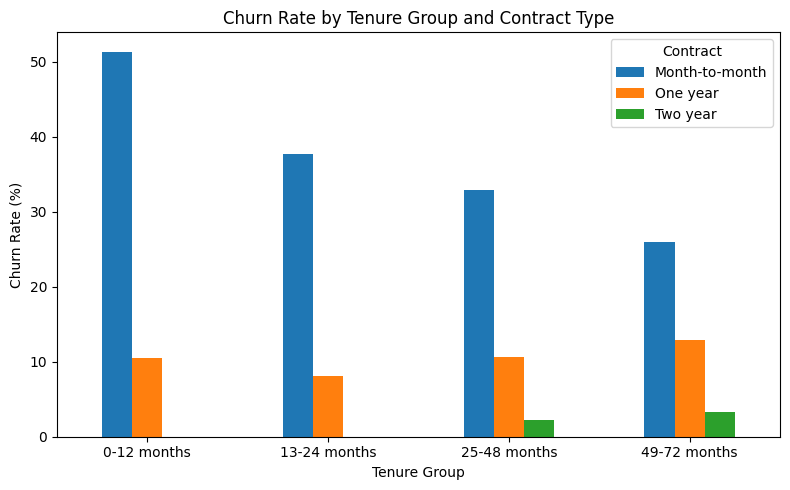

In [108]:
pivot_tenure_contract = tenure_contract_churn.pivot(index="tenure_group", columns="Contract", values="Churn Rate (%)")

pivot_tenure_contract.plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Tenure Group and Contract Type")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Contract")
plt.tight_layout()
plt.show()

> Month-to-month customers show the highest churn across every tenure group, reaching **51.3% among 0–12 month customers**, while one- and two-year contracts remain substantially lower. Contract type remains strongly associated with churn even as tenure increases.

In [109]:
# Tenure and Monthly Charges
tenure_charge_churn = df_clean.groupby(["tenure_group", "Churn"], observed=False)["MonthlyCharges"].mean().round(2).reset_index()

tenure_charge_churn

,tenure_group,Churn,MonthlyCharges
0,0-12 months,No,46.71
1,0-12 months,Yes,66.49
2,13-24 months,No,54.45
3,13-24 months,Yes,78.51
4,25-48 months,No,61.17
5,25-48 months,Yes,84.50
6,49-72 months,No,72.03
7,49-72 months,Yes,92.17


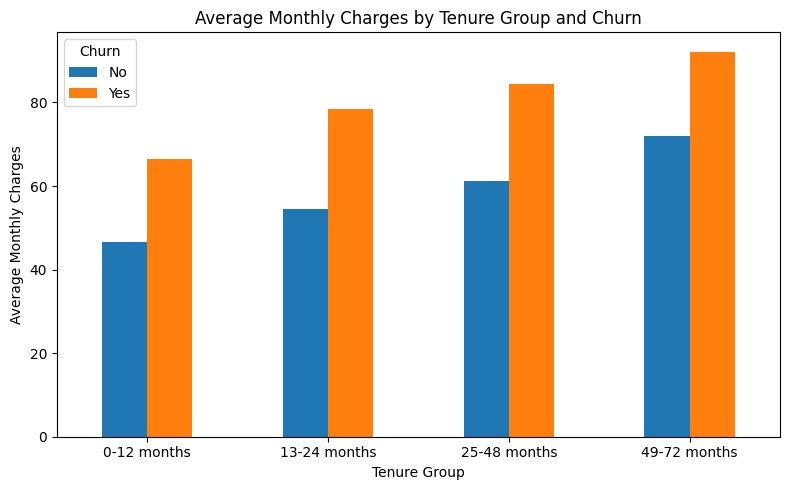

In [110]:
pivot_tenure_charge = tenure_charge_churn.pivot(index="tenure_group", columns="Churn", values="MonthlyCharges")

pivot_tenure_charge.plot(kind="bar", figsize=(8, 5))

plt.title("Average Monthly Charges by Tenure Group and Churn")
plt.xlabel("Tenure Group")
plt.ylabel("Average Monthly Charges")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

> Churned customers have consistently higher average monthly charges than non-churned customers across every tenure group. The gap remains visible even among long-term customers, suggesting that **tenure and recurring charges provide complementary churn signals**.

In [111]:
# Tenure and Internet Service
tenure_internet_churn = df_clean.groupby(["tenure_group", "InternetService"], observed=False)["Churn"].apply(lambda x: (x == "Yes").mean() * 100).round(2).reset_index(name="Churn Rate (%)")

tenure_internet_churn

,tenure_group,InternetService,Churn Rate (%)
0,0-12 months,DSL,40.00
1,0-12 months,Fiber optic,69.88
2,0-12 months,No,17.93
3,13-24 months,DSL,19.64
4,13-24 months,Fiber optic,48.78
5,13-24 months,No,3.77
6,25-48 months,DSL,10.79
7,25-48 months,Fiber optic,36.62
8,25-48 months,No,1.78
9,49-72 months,DSL,4.31


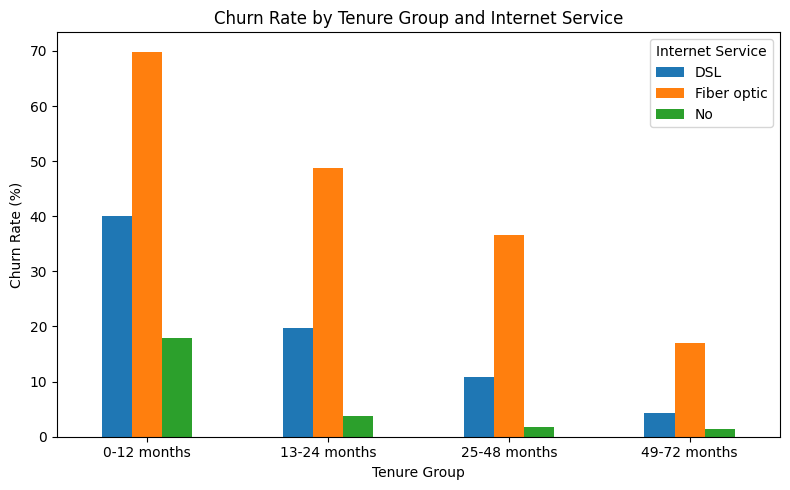

In [112]:
pivot_tenure_internet = tenure_internet_churn.pivot(index="tenure_group", columns="InternetService", values="Churn Rate (%)")

pivot_tenure_internet.plot(kind="bar", figsize=(8, 5))

plt.title("Churn Rate by Tenure Group and Internet Service")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Internet Service")
plt.tight_layout()
plt.show()

> Fiber-optic customers show the highest churn within every tenure group, reaching **~70% among 0–12 month customers** and falling to **~17% among 49–72 month customers**. Churn therefore declines with tenure, but the internet-service difference remains substantial.

In [113]:
# Numerical Feature Relationships
numerical_analysis = df_clean[["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges"]]

correlation_matrix = numerical_analysis.corr()

correlation_matrix

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
SeniorCitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
MonthlyCharges,0.220173,0.247900,1.000000,0.651174
TotalCharges,0.103006,0.826178,0.651174,1.000000


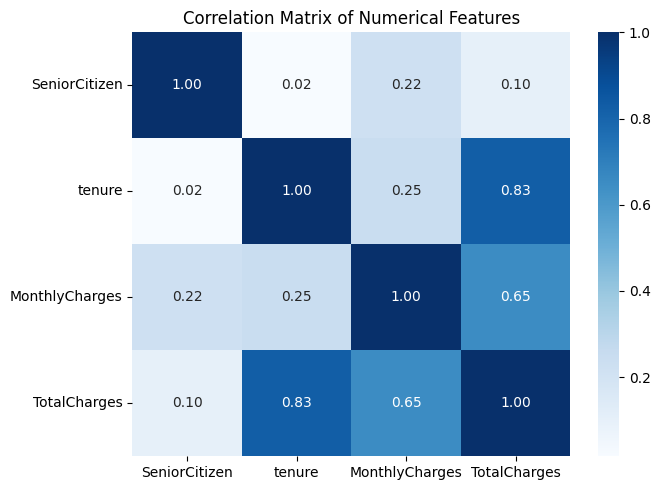

In [114]:
plt.figure(figsize=(7, 5))

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="Blues")

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

> `tenure` and `TotalCharges` show a strong positive correlation (**0.83**), while `MonthlyCharges` and `TotalCharges` also have a notable relationship (**0.65**). These relationships are expected for cumulative billing data and should be considered when interpreting feature importance.

##### Multivariate Analysis — Key Findings

Combining variables reveals stronger churn patterns than several individual analyses. **Contract type, tenure, internet service, and monthly charges** interact to create substantially different customer risk profiles.

These relationships provide useful candidates for model learning; however, observed group differences and correlations indicate association rather than causation.

#### Key Churn Drivers

The exploratory analysis identified several variables with noticeable differences in observed churn rates.

The strongest patterns were found in **contract type, tenure, internet service, tech support, online security, payment method, and customer household characteristics**. These variables will receive particular attention during model development.

In [115]:
key_churn_drivers = pd.DataFrame({
    "Feature": [
        "Contract",
        "Tenure",
        "InternetService",
        "TechSupport",
        "OnlineSecurity",
        "PaymentMethod",
        "SeniorCitizen",
        "Partner",
        "Dependents",
        "MonthlyCharges"
    ],
    "Observed Pattern": [
        "Month-to-month customers show much higher churn",
        "Churn decreases strongly as tenure increases",
        "Fiber optic customers show higher churn",
        "Customers without tech support show higher churn",
        "Customers without online security show higher churn",
        "Electronic check users show higher churn",
        "Senior customers show higher churn",
        "Customers without a partner show higher churn",
        "Customers without dependents show higher churn",
        "Churned customers have higher average monthly charges"
    ]
})

key_churn_drivers

,Feature,Observed Pattern
0,Contract,Month-to-month customers show much higher churn
1,Tenure,Churn decreases strongly as tenure increases
2,InternetService,Fiber optic customers show higher churn
3,TechSupport,Customers without tech support show higher churn
4,OnlineSecurity,Customers without online security show higher ...
5,PaymentMethod,Electronic check users show higher churn
6,SeniorCitizen,Senior customers show higher churn
7,Partner,Customers without a partner show higher churn
8,Dependents,Customers without dependents show higher churn
9,MonthlyCharges,Churned customers have higher average monthly ...


##### Modeling Priorities

Based on the EDA findings, the following variables show the strongest observed churn differences and will be closely examined during model development:

1. Contract
2. Tenure
3. InternetService
4. TechSupport
5. OnlineSecurity
6. PaymentMethod
7. SeniorCitizen
8. Partner
9. Dependents
10. MonthlyCharges

These are **candidate predictors**, not confirmed model drivers. Their actual predictive contribution will be assessed using the trained machine learning models.

##### Association vs. Causation

The EDA findings represent **observed associations within the dataset** and should not be interpreted as causal relationships.

For example, higher churn among customers without technical support does not prove that the absence of technical support causes churn. The machine learning stage will evaluate how these variables contribute to prediction when considered together.

##### Key Business Insight

The strongest observed churn patterns are concentrated around **customer tenure, contract commitment, internet service, support/security services, payment method, and customer characteristics**.

In particular, newer customers and month-to-month customers consistently show higher churn, while several service and billing characteristics further distinguish higher- and lower-churn customer groups.

#### EDA Validation & Business Summary

##### EDA Validation

The exploratory analysis was reviewed across customer characteristics, tenure, services, contracts, billing, and selected feature combinations. The identified patterns were consistent across the corresponding group-level analyses and were retained only where the observed differences were sufficiently noticeable.

The analysis provides a business-oriented understanding of churn patterns and establishes a basis for evaluating these variables through machine learning.

##### EDA Limitations

The findings describe patterns and associations present in the historical dataset. They do not establish that any individual characteristic directly causes customer churn.

Observed group differences may also reflect interactions between multiple customer, service, contract, and billing characteristics. Therefore, individual EDA findings should not be treated as standalone predictors.

##### Business Summary

The exploratory analysis indicates that customer churn is associated with differences across several aspects of the customer relationship, particularly **tenure, contract structure, service configuration, support/security subscriptions, payment behavior, and billing characteristics**.

These findings will guide the subsequent machine learning stage, where multiple features will be considered together to determine how effectively customer churn can be predicted for unseen records.

##### EDA Conclusion

EDA has established the main patterns and relationships present in the customer dataset without making causal assumptions. The resulting insights provide the business context and feature-level understanding required to proceed to **model development and comparison**.

#### Save Cleaned Dataset

In [116]:
# Create processed data directory
processed_data_path = Path("../data/processed")
processed_data_path.mkdir(parents=True, exist_ok=True)

# Remove EDA-only derived column before saving the core cleaned dataset
df_clean_final = df_clean.drop(columns=["tenure_group"], errors="ignore")

# Save cleaned dataset
cleaned_file_path = (processed_data_path / "cleaned_customer_churn.csv")

df_clean_final.to_csv(cleaned_file_path, index=False)

print(f"Cleaned dataset saved to: {cleaned_file_path}")
print(f"Dataset shape: {df_clean_final.shape}")

Cleaned dataset saved to: ..\data\processed\cleaned_customer_churn.csv
Dataset shape: (7043, 21)


In [117]:
# Verify the saved dataset
saved_df = pd.read_csv(cleaned_file_path)

print("File exists:", cleaned_file_path.exists())
print("Saved shape:", saved_df.shape)
print("Missing values:", saved_df.isnull().sum().sum())

File exists: True
Saved shape: (7043, 21)
Missing values: 0


### Model Development

#### Logistic Regression Baseline

Logistic Regression is established as the baseline classification model. Its validation performance will provide a benchmark for comparing the subsequent machine learning models.

In [118]:
# Initialize the Logistic Regression Model
logistic_model = LogisticRegression(max_iter=1000, random_state=42)

In [119]:
# Train Logistic Regression
logistic_model.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [120]:
# Validation Predictions
y_val_pred_lr = logistic_model.predict(X_val_processed)

y_val_proba_lr = logistic_model.predict_proba(X_val_processed)[:, 1]

In [121]:
# Evaluate Baseline Performance
lr_baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_val, y_val_pred_lr),
    "Precision": precision_score(y_val, y_val_pred_lr),
    "Recall": recall_score(y_val, y_val_pred_lr),
    "F1": f1_score(y_val, y_val_pred_lr),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba_lr)
}

lr_baseline_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8058712121212122,
 'Precision': 0.6459143968871596,
 'Recall': 0.5928571428571429,
 'F1': 0.6182495344506518,
 'ROC-AUC': 0.8454321612665685}

In [122]:
# Format Results
lr_baseline_df = pd.DataFrame([lr_baseline_results])

lr_baseline_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]] = lr_baseline_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].round(4)

lr_baseline_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8059,0.6459,0.5929,0.6182,0.8454


##### Baseline Observation

Logistic Regression provides the initial validation benchmark against which the remaining classification models will be compared.

Its performance should be interpreted across multiple metrics rather than accuracy alone because the churn classes are imbalanced.

#### Decision Tree Classifier

A Decision Tree is trained as the second baseline model to determine whether rule-based, non-linear splits can capture useful relationships between customer features and churn.

In [123]:
# Initialize the Decision Tree Model
decision_tree_model = DecisionTreeClassifier(random_state=42)

In [124]:
# Train Decision Tree Model
decision_tree_model.fit(X_train_processed, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [125]:
# Validation Predictions
y_val_pred_dt = decision_tree_model.predict(X_val_processed)

y_val_proba_dt = decision_tree_model.predict_proba(X_val_processed)[:, 1]

In [126]:
# Evaluate Performance
dt_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_score(y_val, y_val_pred_dt),
    "Precision": precision_score(y_val, y_val_pred_dt),
    "Recall": recall_score(y_val, y_val_pred_dt),
    "F1": f1_score(y_val, y_val_pred_dt),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba_dt)
}

dt_results

{'Model': 'Decision Tree',
 'Accuracy': 0.7178030303030303,
 'Precision': 0.4689655172413793,
 'Recall': 0.4857142857142857,
 'F1': 0.47719298245614034,
 'ROC-AUC': 0.6429675994108984}

In [127]:
# Format Results
dt_results_df = pd.DataFrame([dt_results])

dt_results_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]] = dt_results_df[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]].round(4)

dt_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree,0.7178,0.469,0.4857,0.4772,0.643


##### Decision Tree Observation

The Decision Tree provides a second model benchmark for the churn classification task, allowing comparison with the Logistic Regression baseline.

Its performance will be evaluated using the same classification metrics, with particular attention to **Precision, Recall, F1-score, and ROC-AUC** because of the observed class imbalance.

#### Random Forest Classifier

A Random Forest classifier is trained to determine whether an ensemble of decision trees can improve churn prediction compared with the individual baseline models.

In [128]:
# Initialize the Random Forest Model
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [129]:
# Train Decision Tree Model
random_forest_model.fit(X_train_processed, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [130]:
# Validation Predictions
y_val_pred_rf = random_forest_model.predict(X_val_processed)

y_val_proba_rf = random_forest_model.predict_proba(X_val_processed)[:, 1]

In [131]:
# Evaluate Performance
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_val, y_val_pred_rf),
    "Precision": precision_score(y_val, y_val_pred_rf),
    "Recall": recall_score(y_val, y_val_pred_rf),
    "F1": f1_score(y_val, y_val_pred_rf),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba_rf)
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.7755681818181818,
 'Precision': 0.5938864628820961,
 'Recall': 0.4857142857142857,
 'F1': 0.5343811394891945,
 'ROC-AUC': 0.8130983063328424}

In [132]:
# Format Results
rf_results_df = pd.DataFrame([rf_results])

rf_results_df[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
] = rf_results_df[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
].round(4)

rf_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Random Forest,0.7756,0.5939,0.4857,0.5344,0.8131


##### Random Forest — Observation

The Random Forest provides an ensemble-based benchmark for the churn classification task, allowing us to assess whether combining multiple decision trees improves predictive performance.

Its final position will be determined after all candidate models are evaluated using the same validation metrics.

#### Gradient Boosting Classifier

A Gradient Boosting classifier is trained to evaluate whether sequentially built decision trees can capture complex relationships between customer characteristics and churn.

In [133]:
# Initialize the Gradient Boosting Model
gradient_boosting_model = GradientBoostingClassifier(random_state=42)

In [134]:
# Train Gradient Boosting Model
gradient_boosting_model.fit(X_train_processed, y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [135]:
# Validation Predictions
y_val_pred_gb = gradient_boosting_model.predict(X_val_processed)

y_val_proba_gb = gradient_boosting_model.predict_proba(X_val_processed)[:, 1]

In [136]:
# Evaluate Performance
gb_results = {
    "Model": "Gradient Boosting",
    "Accuracy": accuracy_score(y_val, y_val_pred_gb),
    "Precision": precision_score(y_val, y_val_pred_gb),
    "Recall": recall_score(y_val, y_val_pred_gb),
    "F1": f1_score(y_val, y_val_pred_gb),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba_gb)
}

gb_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.8020833333333334,
 'Precision': 0.6577777777777778,
 'Recall': 0.5285714285714286,
 'F1': 0.5861386138613861,
 'ROC-AUC': 0.8474318851251841}

In [137]:
# Format Results
gb_results_df = pd.DataFrame([gb_results])

gb_results_df[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
] = gb_results_df[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
].round(4)

gb_results_df

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Gradient Boosting,0.8021,0.6578,0.5286,0.5861,0.8474


##### Gradient Boosting — Observation

Gradient Boosting provides the fourth candidate model for the churn classification task and evaluates whether sequential ensemble learning can improve predictive performance.

Its final performance will be assessed alongside the other candidate models during the consolidated model comparison.

#### Model Comparison

In [138]:
# Collect validation results from all four candidate models

model_comparison = pd.DataFrame([lr_baseline_results, dt_results, rf_results, gb_results])

# Round evaluation metrics for readability
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]

model_comparison[metrics] = model_comparison[metrics].round(4)

model_comparison = model_comparison.sort_values(by="F1", ascending=False).reset_index(drop=True)

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8059,0.6459,0.5929,0.6182,0.8454
1,Gradient Boosting,0.8021,0.6578,0.5286,0.5861,0.8474
2,Random Forest,0.7756,0.5939,0.4857,0.5344,0.8131
3,Decision Tree,0.7178,0.4690,0.4857,0.4772,0.6430


##### Analysis

- **Logistic Regression currently performs best overall**, achieving the highest Accuracy (**80.59%**), Recall (**59.29%**), and F1-score (**61.82%**).
- **Gradient Boosting has the highest ROC-AUC (84.74%)** and slightly higher Precision **(65.78%)**, indicating strong ability to distinguish between churned and non-churned customers.
- **Random Forest and Decision Tree underperform** the two leading models across the main evaluation metrics, with Decision Tree showing the weakest overall performance.
- Since the business objective is **churn prediction**, Recall and F1-score are particularly important because failing to identify an actual churner can reduce the usefulness of the retention system.

##### Model Comparison — Conclusion

Logistic Regression provides the strongest overall validation performance, particularly in Recall and F1-score, while Gradient Boosting achieves the highest ROC-AUC and Precision.

Both models will therefore be considered for further optimization rather than selecting a final model solely from the initial validation results.

### Model Optimization & Evaluation

#### Model Evaluation Criteria

The churn prediction models will be evaluated using multiple classification metrics rather than accuracy alone.

- **Recall:** Measures how many actual churners are successfully identified.
- **Precision:** Measures how many customers predicted as churners actually churn.
- **F1-score:** Balances Precision and Recall.
- **ROC-AUC:** Measures how effectively the model separates churned and non-churned customers.
- **Accuracy:** Measures the overall proportion of correct predictions.

##### Primary Model Selection Metric

For this churn prediction problem, **F1-score will be used as the primary model-selection metric** because it provides a balance between identifying actual churners and avoiding excessive false churn predictions.

**Recall will receive particular attention** because failing to identify a customer who actually churns can represent a missed retention opportunity.

ROC-AUC, Precision, and Accuracy will be used as supporting evaluation metrics.

##### Business Objective

The practical objective is to build a model that can reliably identify customers who are likely to churn so that the business can prioritize them for potential retention actions.

The final model should therefore provide a useful balance between **capturing genuine churners and maintaining reasonable prediction precision**, rather than maximizing accuracy alone.

#### Analyze Confusion Matrices

A confusion matrix shows how the model's predictions are distributed across the actual churn outcomes.

- **True Positive (TP):** Actual churner correctly predicted as churner.
- **True Negative (TN):** Non-churner correctly predicted as non-churner.
- **False Positive (FP):** Non-churner incorrectly predicted as churner.
- **False Negative (FN):** Actual churner incorrectly predicted as non-churner.

In [139]:
cm_lr = confusion_matrix(y_val, y_val_pred_lr)
cm_gb = confusion_matrix(y_val, y_val_pred_gb)

print("Logistic Regression:")
print(cm_lr)

print("\nGradient Boosting:")
print(cm_gb)

Logistic Regression:
[[685  91]
 [114 166]]

Gradient Boosting:
[[699  77]
 [132 148]]


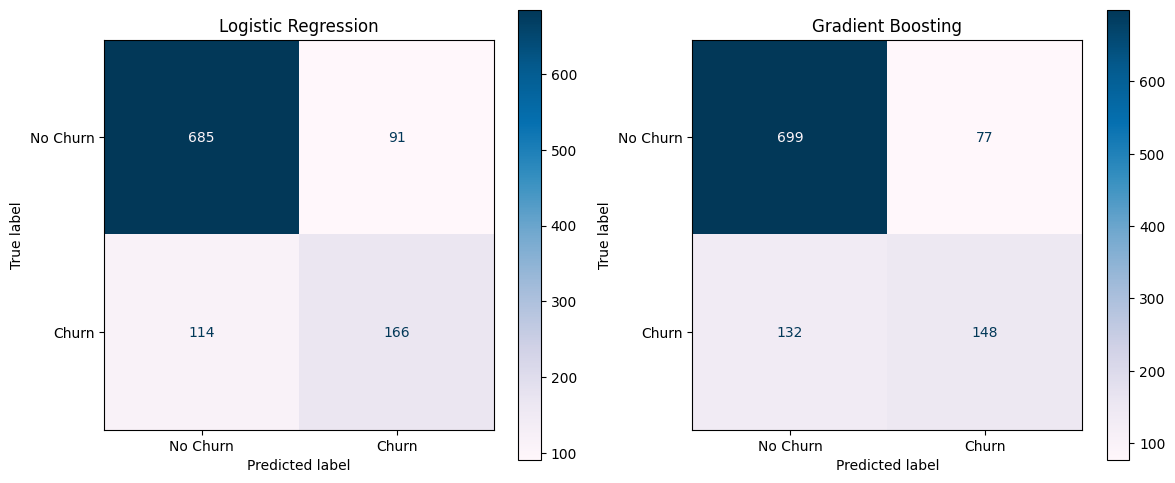

In [140]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["No Churn", "Churn"]).plot(ax=axes[0], cmap="PuBu")

axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(confusion_matrix=cm_gb, display_labels=["No Churn", "Churn"]).plot(ax=axes[1], cmap="PuBu")

axes[1].set_title("Gradient Boosting")

plt.tight_layout()
plt.show()

In [141]:
tn_lr, fp_lr, fn_lr, tp_lr = cm_lr.ravel()
tn_gb, fp_gb, fn_gb, tp_gb = cm_gb.ravel()

confusion_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Gradient Boosting"
    ],
    "True Negatives": [tn_lr, tn_gb],
    "False Positives": [fp_lr, fp_gb],
    "False Negatives": [fn_lr, fn_gb],
    "True Positives": [tp_lr, tp_gb]
})

confusion_summary

,Model,True Negatives,False Positives,False Negatives,True Positives
0,Logistic Regression,685,91,114,166
1,Gradient Boosting,699,77,132,148


##### Confusion Matrix — Key Findings

Logistic Regression identifies more actual churners, with **166 true positives and 114 false negatives**, compared with Gradient Boosting's **148 true positives and 132 false negatives**. This supports the higher Recall observed for Logistic Regression.

Gradient Boosting produces fewer false positives (**77 vs. 91**) but also misses more actual churners. Given the retention objective, Logistic Regression currently provides the more favorable error balance.

#### Hyperparameter Optimization

Hyperparameter optimization is used to identify model settings that improve predictive performance without relying on the final test set.

The optimization will focus on Logistic Regression and Gradient Boosting because they produced the strongest initial validation results.

##### Logistic Regression Tuning

In [142]:
# Logistic Regression Tuning
lr_param_grid = {"C": [0.01, 0.1, 1, 10, 100], "solver": ["liblinear", "lbfgs"]}

lr_grid = GridSearchCV(estimator=LogisticRegression(max_iter=2000, random_state=42), param_grid=lr_param_grid, scoring="f1", cv=5, n_jobs=-1)

lr_grid.fit(X_train_processed, y_train)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [143]:
print("Best Logistic Regression parameters:")
print(lr_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(round(lr_grid.best_score_, 4))

Best Logistic Regression parameters:
{'C': 100, 'solver': 'liblinear'}

Best cross-validation F1-score:
0.6006


In [144]:
# Evaluate Optimized Logistic Regression
optimized_lr = lr_grid.best_estimator_

y_val_pred_lr_opt = optimized_lr.predict(X_val_processed)
y_val_proba_lr_opt = optimized_lr.predict_proba(X_val_processed)[:, 1]

In [145]:
optimized_lr_results = {
    "Model": "Optimized Logistic Regression",
    "Accuracy": accuracy_score(y_val, y_val_pred_lr_opt),
    "Precision": precision_score(y_val, y_val_pred_lr_opt),
    "Recall": recall_score(y_val, y_val_pred_lr_opt),
    "F1": f1_score(y_val, y_val_pred_lr_opt),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba_lr_opt)
}

pd.DataFrame([optimized_lr_results]).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Optimized Logistic Regression,0.8068,0.6484,0.5929,0.6194,0.8453


##### Gradient Boosting Tuning

In [146]:
# Gradient Boosting Tuning
gb_param_grid = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

gb_grid = GridSearchCV(estimator=GradientBoostingClassifier(random_state=42), param_grid=gb_param_grid, scoring="f1", cv=5, n_jobs=-1)

gb_grid.fit(X_train_processed, y_train)

,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'log_loss'


In [147]:
print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

print("\nBest cross-validation F1-score:")
print(round(gb_grid.best_score_, 4))

Best Gradient Boosting parameters:
{'learning_rate': 0.1, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best cross-validation F1-score:
0.5896


In [148]:
# Evaluate Optimized Gradient Boosting
optimized_gb = gb_grid.best_estimator_

y_val_pred_gb_opt = optimized_gb.predict(X_val_processed)

y_val_proba_gb_opt = optimized_gb.predict_proba(X_val_processed)[:, 1]

In [149]:
optimized_gb_results = {
    "Model": "Optimized Gradient Boosting",
    "Accuracy": accuracy_score(y_val, y_val_pred_gb_opt),
    "Precision": precision_score(y_val, y_val_pred_gb_opt),
    "Recall": recall_score(y_val, y_val_pred_gb_opt),
    "F1": f1_score(y_val, y_val_pred_gb_opt),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba_gb_opt)
}

pd.DataFrame([optimized_gb_results]).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Optimized Gradient Boosting,0.804,0.6667,0.5214,0.5852,0.8522


##### Optimization Comparison

In [150]:
optimization_results = pd.DataFrame([
    lr_baseline_results,
    optimized_lr_results,
    gb_results,
    optimized_gb_results
])

optimization_results[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
] = optimization_results[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
].round(4)

optimization_results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8059,0.6459,0.5929,0.6182,0.8454
1,Optimized Logistic Regression,0.8068,0.6484,0.5929,0.6194,0.8453
2,Gradient Boosting,0.8021,0.6578,0.5286,0.5861,0.8474
3,Optimized Gradient Boosting,0.8040,0.6667,0.5214,0.5852,0.8522


##### Hyperparameter Optimization — Key Findings

Hyperparameter tuning produced only a marginal improvement for Logistic Regression, increasing **F1 from 0.6182 to 0.6194** and Accuracy from **80.59% to 80.68%**, while Recall remained unchanged at **59.29%**.

For Gradient Boosting, optimization slightly reduced F1 (**0.5861 → 0.5852**) and Recall (**52.86% → 52.14%**), although ROC-AUC improved from **0.8474 to 0.8522**. Overall, tuning did not produce a meaningful improvement in the primary F1-based objective.

##### Optimization Decision

The optimized Logistic Regression model currently provides the strongest overall balance of performance metrics and shows a small improvement over its baseline.

Gradient Boosting does not show sufficient improvement in the primary F1 and Recall metrics to replace Logistic Regression at this stage. Both models will still be considered when evaluating the class-imbalance strategy.

#### Class Imbalance Evaluation

The selected Logistic Regression model will be evaluated in two configurations:

1. **Optimized Logistic Regression** — the configuration identified during hyperparameter optimization.
2. **Balanced Logistic Regression** — the same optimized configuration with `class_weight="balanced"` to give greater importance to the minority churn class.

Their validation performance will be compared to determine whether class weighting improves churn identification.

In [151]:
# Train Balanced Logistic Regression
balanced_lr = LogisticRegression(
    C=lr_grid.best_params_["C"],
    solver=lr_grid.best_params_["solver"],
    max_iter=2000,
    class_weight="balanced",
    random_state=42
)

balanced_lr.fit(X_train_processed, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,100
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'liblinear'
,max_iter,2000
,multi_class,'deprecated'


In [152]:
# Validation Predictions
y_val_pred_balanced = balanced_lr.predict(X_val_processed)

y_val_proba_balanced = balanced_lr.predict_proba(X_val_processed)[:, 1]

In [153]:
# Evaluate Balanced Model
balanced_lr_results = {
    "Model": "Balanced Logistic Regression",
    "Accuracy": accuracy_score(y_val, y_val_pred_balanced),
    "Precision": precision_score(y_val, y_val_pred_balanced),
    "Recall": recall_score(y_val, y_val_pred_balanced),
    "F1": f1_score(y_val, y_val_pred_balanced),
    "ROC-AUC": roc_auc_score(y_val, y_val_proba_balanced)
}

pd.DataFrame([balanced_lr_results]).round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Balanced Logistic Regression,0.7348,0.5,0.8143,0.6196,0.8447


In [154]:
class_imbalance_comparison = pd.DataFrame([
    optimized_lr_results,
    balanced_lr_results
])

class_imbalance_comparison[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
] = class_imbalance_comparison[
    ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
].round(4)

class_imbalance_comparison

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Optimized Logistic Regression,0.8068,0.6484,0.5929,0.6194,0.8453
1,Balanced Logistic Regression,0.7348,0.5000,0.8143,0.6196,0.8447


##### Prediction Threshold Analysis

The default classification threshold is 0.50. Different thresholds will be evaluated using the validation probabilities to determine whether another threshold provides a more useful balance between Precision and Recall for churn prediction.

The test set will remain untouched during this analysis.

In [155]:
threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):
    y_threshold_pred = (
        y_val_proba_lr_opt >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": round(threshold, 2),
        "Precision": precision_score(
            y_val, y_threshold_pred
        ),
        "Recall": recall_score(
            y_val, y_threshold_pred
        ),
        "F1": f1_score(
            y_val, y_threshold_pred
        )
    })

threshold_results_df = pd.DataFrame(threshold_results).round(4)

threshold_results_df

,Threshold,Precision,Recall,F1
0,0.30,0.5176,0.7893,0.6252
1,0.35,0.5359,0.7464,0.6239
2,0.40,0.5613,0.7036,0.6244
3,0.45,0.5948,0.6500,0.6212
4,0.50,0.6484,0.5929,0.6194
5,0.55,0.6837,0.5250,0.5939
6,0.60,0.7188,0.4107,0.5227
7,0.65,0.7333,0.3143,0.4400
8,0.70,0.7105,0.1929,0.3034


In [156]:
# Identify Best Threshold by F1
best_threshold_row = threshold_results_df.loc[threshold_results_df["F1"].idxmax()]

best_threshold_row

Threshold    0.3000
Precision    0.5176
Recall       0.7893
F1           0.6252
Name: 0, dtype: float64

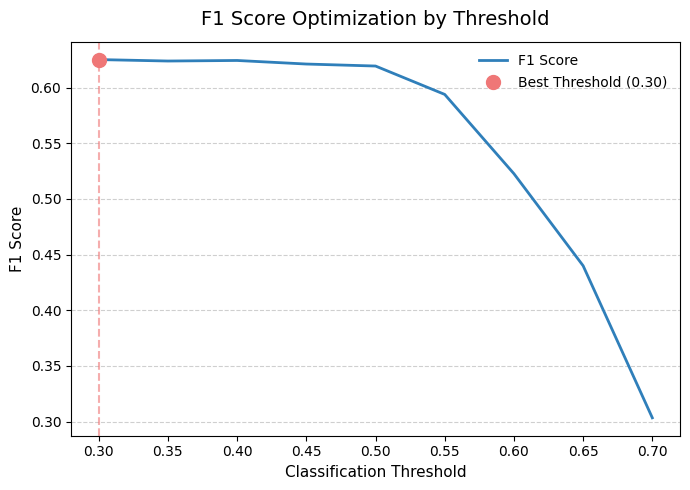

In [ ]:
plt.figure(figsize=(7, 5))

# Plot the F1 scores across all thresholds
sns.lineplot(data=threshold_results_df, x="Threshold", y="F1", color="#2f7fba", linewidth=2, label="F1 Score")

# Highlight the best threshold point
best_threshold = best_threshold_row["Threshold"]
best_f1 = best_threshold_row["F1"]

plt.scatter(x=best_threshold, y=best_f1, color="#ef7777", s=100, zorder=5, label=f"Best Threshold ({best_threshold:.2f})")

# Add a vertical dotted line for emphasis
plt.axvline(x=best_threshold, color="#ef7777", linestyle="--", alpha=0.6)

# Formatting
plt.title("F1 Score Optimization by Threshold", fontsize=14, pad=12)
plt.xlabel("Classification Threshold", fontsize=11)
plt.ylabel("F1 Score", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.legend(frameon=False)

# Optimize layout and display
plt.tight_layout()
plt.show()

##### Class Imbalance — Key Findings

Using `class_weight="balanced"` increased Recall substantially from **59.29% to 81.43%**, but reduced Precision from **64.84% to 50.00%** and did not meaningfully improve F1 (**0.6194 → 0.6196**).

Threshold tuning of the optimized Logistic Regression produced a stronger result at **0.30**, achieving **78.93% Recall, 51.76% Precision, and 62.52% F1**, making it the best configuration evaluated so far for the primary F1 objective.

##### Class Imbalance — Key Findings

Using `class_weight="balanced"` increased Recall substantially from **59.29% to 81.43%**, but reduced Precision from **64.84% to 50.00%** and did not meaningfully improve F1 (**0.6194 → 0.6196**).

Threshold tuning of the optimized Logistic Regression produced a stronger result at **0.30**, achieving **78.93% Recall, 51.76% Precision, and 62.52% F1**, making it the best configuration evaluated so far for the primary F1 objective.

##### Final Model Configuration

- **Model:** Optimized Logistic Regression
- **Threshold:** 0.30
- **F1:** 0.6252
- **Recall:** 0.7893
- **Precision:** 0.5176

#### Final Test Evaluation

The optimized Logistic Regression model with a **0.30 prediction threshold** is now evaluated on the previously untouched test set.

This provides an unbiased estimate of how the finalized churn prediction configuration performs on unseen data.

In [157]:
# Generate test-set probabilities
y_test_proba = optimized_lr.predict_proba(X_test_processed)[:, 1]

# Apply the selected 0.30 threshold
final_threshold = 0.30

y_test_pred = (y_test_proba >= final_threshold).astype(int)

In [158]:
final_test_results = {
    "Model": "Optimized Logistic Regression",
    "Threshold": final_threshold,
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred),
    "Recall": recall_score(y_test, y_test_pred),
    "F1": f1_score(y_test, y_test_pred),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba)
}

pd.DataFrame([final_test_results]).round(4)

,Model,Threshold,Accuracy,Precision,Recall,F1,ROC-AUC
0,Optimized Logistic Regression,0.3,0.7663,0.544,0.7473,0.6297,0.8446


In [159]:
final_cm = confusion_matrix(y_test, y_test_pred)

print(final_cm)

[[600 176]
 [ 71 210]]


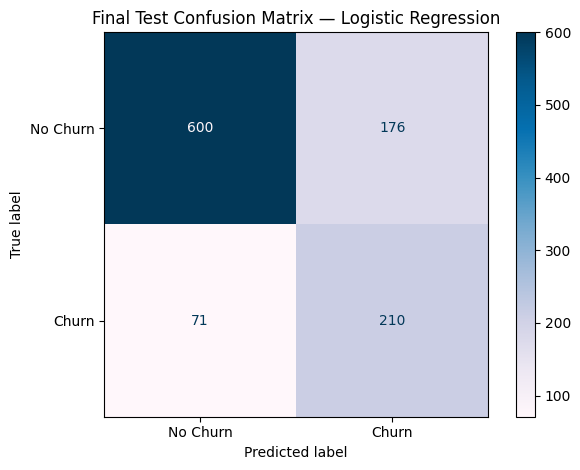

In [160]:
ConfusionMatrixDisplay(confusion_matrix=final_cm, display_labels=["No Churn", "Churn"]).plot(cmap="PuBu")

plt.title("Final Test Confusion Matrix — Logistic Regression")

plt.tight_layout()
plt.show()

##### Final Test Confusion Matrix — Key Findings

The confusion matrix shows **600 true negatives**, meaning 600 customers who did not churn were correctly identified, and **210 true positives**, meaning 210 actual churners were correctly identified.

The model produced **176 false positives** (non-churners predicted as churners) and **71 false negatives** (actual churners predicted as non-churners). The relatively lower number of false negatives reflects the selected **0.30 threshold**, which prioritizes identifying potential churners.

##### Final Test Evaluation — Findings

The finalized Logistic Regression model was evaluated on the untouched test set using a **0.30 prediction threshold**.

The final results were:

- Accuracy: **76.63%**
- Precision: **54.4%**
- Recall: **74.73%**
- F1-score: **62.97%**
- ROC-AUC: **84.46**

These results provide the final unbiased assessment of the model's ability to identify customers at risk of churn.

#### Model Interpretation

##### Extract Transformed Feature Names

The preprocessing pipeline transforms categorical variables into multiple encoded features and scales numerical variables.

To interpret the Logistic Regression model, we first retrieve the feature names generated by the fitted preprocessing pipeline.

In [161]:
feature_names = preprocessor.get_feature_names_out()

print(f"Total transformed features: {len(feature_names)}")
print(feature_names[:20])

Total transformed features: 45
['num__SeniorCitizen' 'num__tenure' 'num__MonthlyCharges'
 'num__TotalCharges' 'cat__gender_Female' 'cat__gender_Male'
 'cat__Partner_No' 'cat__Partner_Yes' 'cat__Dependents_No'
 'cat__Dependents_Yes' 'cat__PhoneService_No' 'cat__PhoneService_Yes'
 'cat__MultipleLines_No' 'cat__MultipleLines_No phone service'
 'cat__MultipleLines_Yes' 'cat__InternetService_DSL'
 'cat__InternetService_Fiber optic' 'cat__InternetService_No'
 'cat__OnlineSecurity_No' 'cat__OnlineSecurity_No internet service']


##### Extract Logistic Regression Coefficients

Logistic Regression assigns a coefficient to each transformed feature.

- **Positive coefficient:** associated with higher predicted churn likelihood.
- **Negative coefficient:** associated with lower predicted churn likelihood.
- Larger absolute values indicate stronger influence on the model's decision, within the context of the transformed feature representation.

In [162]:
coefficients = optimized_lr.coef_[0]

coefficient_df = pd.DataFrame({"Feature": feature_names, "Coefficient": coefficients})

coefficient_df.head()

,Feature,Coefficient
0,num__SeniorCitizen,0.052313
1,num__tenure,-1.393007
2,num__MonthlyCharges,-2.029078
3,num__TotalCharges,0.715557
4,cat__gender_Female,-0.244025


##### Measure Feature Influence

The absolute value of each coefficient is calculated to identify features with the strongest influence on the model's predictions, regardless of direction.

In [163]:
coefficient_df["Absolute Coefficient"] = (coefficient_df["Coefficient"].abs())

coefficient_df = coefficient_df.sort_values("Absolute Coefficient", ascending=False)

coefficient_df.head(15)

,Feature,Coefficient,Absolute Coefficient
2,num__MonthlyCharges,-2.029078,2.029078
1,num__tenure,-1.393007,1.393007
16,cat__InternetService_Fiber optic,1.247523,1.247523
15,cat__InternetService_DSL,-1.098177,1.098177
38,cat__Contract_Two year,-0.804130,0.804130
3,num__TotalCharges,0.715557,0.715557
17,cat__InternetService_No,-0.608081,0.608081
28,cat__TechSupport_No internet service,-0.608081,0.608081
25,cat__DeviceProtection_No internet service,-0.608081,0.608081
19,cat__OnlineSecurity_No internet service,-0.608081,0.608081


##### Strongest Positive Churn Associations

The features with the largest positive coefficients are identified to determine which transformed customer characteristics are most strongly associated with higher predicted churn likelihood.

In [164]:
top_positive = (coefficient_df .sort_values("Coefficient", ascending=False).head(10)[["Feature", "Coefficient"]])

top_positive

,Feature,Coefficient
16,cat__InternetService_Fiber optic,1.247523
3,num__TotalCharges,0.715557
36,cat__Contract_Month-to-month,0.537653
35,cat__StreamingMovies_Yes,0.533887
32,cat__StreamingTV_Yes,0.485481
14,cat__MultipleLines_Yes,0.343156
26,cat__DeviceProtection_Yes,0.207690
43,cat__PaymentMethod_Electronic check,0.153768
23,cat__OnlineBackup_Yes,0.141956
18,cat__OnlineSecurity_No,0.124416


> The strongest positive coefficients include **Fiber optic internet service (1.25)**, **TotalCharges (0.72)**, and **month-to-month contracts (0.54)**. These features are associated with higher predicted churn likelihood within the fitted Logistic Regression model.

##### Strongest Negative Churn Associations

The features with the most negative coefficients are identified to determine which transformed customer characteristics are most strongly associated with lower predicted churn likelihood.

In [165]:
top_negative = (coefficient_df.sort_values("Coefficient", ascending=True).head(10)[["Feature", "Coefficient"]])

top_negative

,Feature,Coefficient
2,num__MonthlyCharges,-2.029078
1,num__tenure,-1.393007
15,cat__InternetService_DSL,-1.098177
38,cat__Contract_Two year,-0.804130
28,cat__TechSupport_No internet service,-0.608081
17,cat__InternetService_No,-0.608081
19,cat__OnlineSecurity_No internet service,-0.608081
25,cat__DeviceProtection_No internet service,-0.608081
31,cat__StreamingTV_No internet service,-0.608081
34,cat__StreamingMovies_No internet service,-0.608081


> The strongest negative coefficients include **MonthlyCharges (-2.03)**, **tenure (-1.39)**, **DSL internet service (-1.10)**, and **two-year contracts (-0.80)**. These coefficients indicate lower model-predicted churn likelihood relative to their encoded reference conditions.

##### Logistic Regression Coefficient Analysis

The strongest positive and negative coefficients are visualized to make the model's learned relationships easier to interpret.

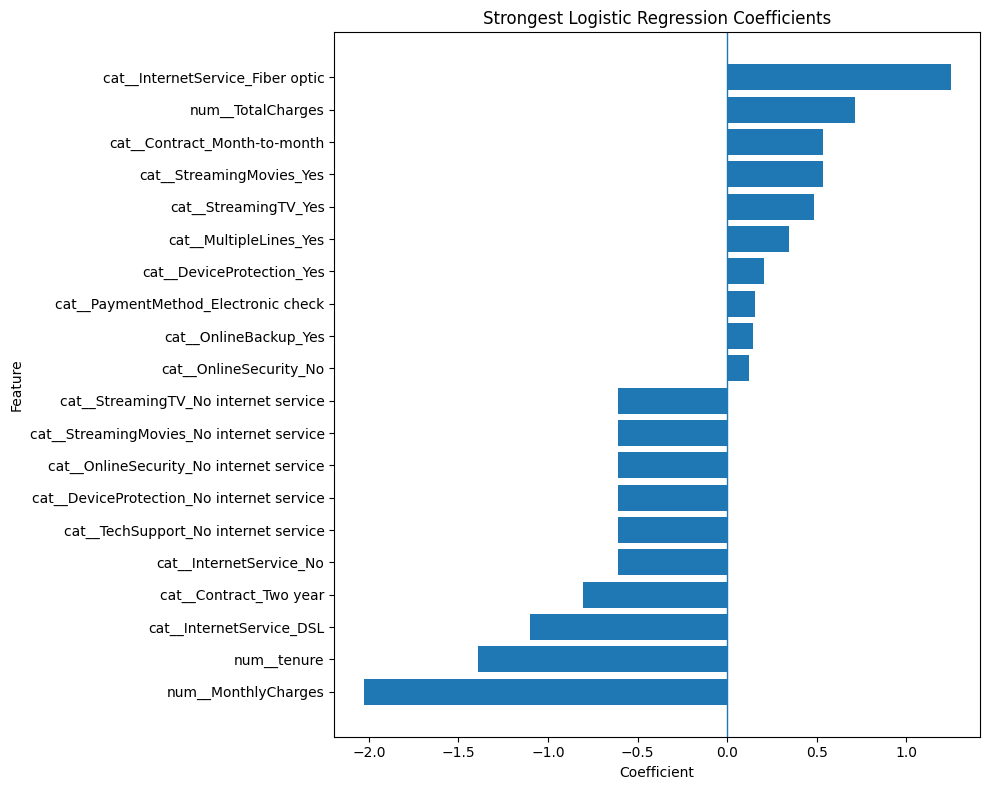

In [166]:
top_coefficients = pd.concat([coefficient_df.sort_values("Coefficient", ascending=False).head(10), coefficient_df.sort_values("Coefficient", ascending=True).head(10)]).drop_duplicates()

top_coefficients = top_coefficients.sort_values("Coefficient")

plt.figure(figsize=(10, 8))

plt.barh(top_coefficients["Feature"], top_coefficients["Coefficient"])

plt.axvline(0, linewidth=1)

plt.title("Strongest Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

##### Clean Feature Names

The transformed names contain prefixes such as num__ and cat__. We can create a cleaner presentation version without altering the underlying model.

In [167]:
coefficient_df["Display Feature"] = (coefficient_df["Feature"].str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False))

coefficient_df[["Display Feature", "Coefficient", "Absolute Coefficient"]].head(15)

,Display Feature,Coefficient,Absolute Coefficient
2,MonthlyCharges,-2.029078,2.029078
1,tenure,-1.393007,1.393007
16,InternetService_Fiber optic,1.247523,1.247523
15,InternetService_DSL,-1.098177,1.098177
38,Contract_Two year,-0.804130,0.804130
3,TotalCharges,0.715557,0.715557
17,InternetService_No,-0.608081,0.608081
28,TechSupport_No internet service,-0.608081,0.608081
25,DeviceProtection_No internet service,-0.608081,0.608081
19,OnlineSecurity_No internet service,-0.608081,0.608081


##### Model Interpretation — Key Findings

The Logistic Regression model identified **MonthlyCharges, tenure, InternetService, contract type, and TotalCharges** among the strongest predictive features. `InternetService_Fiber optic` has the strongest positive coefficient (**1.25**), while `MonthlyCharges` has the largest negative coefficient (**-2.03**) in the standardized model.

Several model-level patterns are consistent with the EDA, particularly the importance of **tenure, fiber-optic service, and contract type**. However, coefficient signs must be interpreted within the full multivariable model because correlated features such as `tenure`, `MonthlyCharges`, and `TotalCharges` can influence each other's coefficients.

#### Final Predictive Pipeline

The finalized preprocessing pipeline and optimized Logistic Regression model are combined into a single reusable pipeline.

The pipeline accepts customer data in its original feature format, applies the required preprocessing, and produces churn probabilities and predictions.

The selected prediction threshold is **0.30**, based on the validation analysis.

In [168]:
final_threshold = 0.30

final_pipeline = Pipeline([("preprocessor", preprocessor), ("model", optimized_lr)])

print("Final predictive pipeline created successfully.")

Final predictive pipeline created successfully.


In [169]:
# Pipeline Validation

In [170]:
pipeline_test_probabilities = final_pipeline.predict_proba(X_test)[:, 1]

pipeline_test_predictions = (pipeline_test_probabilities >= final_threshold).astype(int)

print("Predictions generated successfully.")
print("Number of predictions:", len(pipeline_test_predictions))

Predictions generated successfully.
Number of predictions: 1057


In [171]:
# Verify Predictions Against Final Model
original_test_predictions = y_test_pred

print(
    "Predictions identical:",
    np.array_equal(pipeline_test_predictions, original_test_predictions)
)

Predictions identical: True


> The packaged pipeline produces the same test-set predictions as the finalized model used during the final evaluation.

> This confirms that preprocessing and model inference have been combined correctly without changing the established prediction behavior.

In [172]:
# Save Final Predictive Engine
final_artifact = {"pipeline": final_pipeline, "threshold": final_threshold}

joblib.dump(final_artifact, "../models/churn_prediction_pipeline.joblib")

print("Final predictive engine saved successfully.")

Final predictive engine saved successfully.


In [173]:
# Load the Saved Predictive Engine
loaded_artifact = joblib.load("../models/churn_prediction_pipeline.joblib")

loaded_pipeline = loaded_artifact["pipeline"]
loaded_threshold = loaded_artifact["threshold"]

print("Loaded threshold:", loaded_threshold)

Loaded threshold: 0.3


In [174]:
# Unseen Customer Prediction
unseen_customer = X_test.iloc[[0]].copy()

unseen_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
1639,Male,1,No,No,17,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,45.05,770.6


In [175]:
# Generate Probability and Prediction
churn_probability = loaded_pipeline.predict_proba(unseen_customer)[:, 1][0]

churn_prediction = int(churn_probability >= loaded_threshold)

print(f"Churn Probability: {churn_probability:.2%}")
print(
    "Prediction:",
    "Churn" if churn_prediction == 1 else "No Churn"
)

Churn Probability: 41.86%
Prediction: Churn


In [176]:
# Generate Risk Level
def get_risk_level(probability):
    if probability >= 0.70:
        return "High"
    elif probability >= 0.40:
        return "Medium"
    else:
        return "Low"


risk_level = get_risk_level(churn_probability)

print("Risk Level:", risk_level)

Risk Level: Medium


In [177]:
# Final Prediction Output
prediction_result = pd.DataFrame({
    "Churn Probability": [f"{churn_probability:.2%}"],
    "Prediction": [
        "Churn" if churn_prediction == 1 else "No Churn"
    ],
    "Risk Level": [risk_level]
})

prediction_result

,Churn Probability,Prediction,Risk Level
0,41.86%,Churn,Medium


##### Predictive Engine — Final Demonstration

The saved predictive engine successfully processes an unseen customer record and generates a churn probability, binary churn prediction, and risk level using the finalized preprocessing, Logistic Regression model, and **0.30 prediction threshold**.

The same pipeline can now be reused for future customer records without repeating the training process.

### Predictive Engine Testing

In [178]:
artifact = joblib.load("../models/churn_prediction_pipeline.joblib")

loaded_pipeline = artifact["pipeline"]
loaded_threshold = artifact["threshold"]

print("Pipeline loaded successfully.")
print(f"Prediction threshold: {loaded_threshold}")

Pipeline loaded successfully.
Prediction threshold: 0.3


In [179]:
sample_customers = X_test.iloc[:10].copy()

sample_customers

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
1639,Male,1,No,No,17,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,45.05,770.60
3776,Male,0,Yes,No,43,Yes,No,DSL,No,No,No,No,Yes,No,One year,Yes,Mailed check,56.35,2391.15
805,Female,0,Yes,Yes,72,Yes,Yes,DSL,No,No,Yes,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),76.80,5468.45
2923,Male,0,No,No,54,Yes,No,Fiber optic,Yes,No,Yes,No,Yes,No,Month-to-month,No,Mailed check,89.80,4667.00
5392,Male,0,Yes,Yes,63,No,No phone service,DSL,No,Yes,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),39.35,2395.05
3789,Male,0,No,No,9,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.85,178.80
3466,Male,0,Yes,Yes,72,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),25.10,1790.80
602,Female,0,Yes,Yes,66,Yes,Yes,Fiber optic,No,No,No,No,No,No,One year,Yes,Bank transfer (automatic),74.25,4859.25
2976,Male,0,No,Yes,19,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Credit card (automatic),24.10,439.20
1731,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.60


In [180]:
probabilities = loaded_pipeline.predict_proba(sample_customers)[:, 1]

predictions = (probabilities >= loaded_threshold).astype(int)

prediction_results = sample_customers.copy()

prediction_results["Churn Probability"] = probabilities
prediction_results["Prediction"] = predictions

prediction_results["Prediction"] = prediction_results["Prediction"].map({0: "No Churn", 1: "Churn"})

prediction_results["Risk Level"] = pd.cut(probabilities, bins=[-float("inf"), 0.40, 0.70, float("inf")], labels=["Low", "Medium", "High"])

prediction_results[["Churn Probability", "Prediction", "Risk Level"]]

,Churn Probability,Prediction,Risk Level
1639,0.418565,Churn,Medium
3776,0.083696,No Churn,Low
805,0.025550,No Churn,Low
2923,0.153242,No Churn,Low
5392,0.006164,No Churn,Low
3789,0.140117,No Churn,Low
3466,0.002633,No Churn,Low
602,0.085516,No Churn,Low
2976,0.124726,No Churn,Low
1731,0.736151,Churn,High


In [181]:
reloaded_predictions = (loaded_pipeline.predict_proba(X_test)[:, 1] >= loaded_threshold).astype(int)

print("Predictions match final evaluation:", np.array_equal(reloaded_predictions, y_test_pred))

Predictions match final evaluation: True


In [182]:
print(
    "Minimum probability:",
    round(probabilities.min(), 4)
)

print(
    "Maximum probability:",
    round(probabilities.max(), 4)
)

Minimum probability: 0.0026
Maximum probability: 0.7362


In [183]:
risk_counts = prediction_results["Risk Level"].value_counts().sort_index()

risk_counts

Risk Level
Low       8
Medium    1
High      1
Name: count, dtype: int64

In [184]:
missing_customer = sample_customers.iloc[[0]].copy()

missing_customer.iloc[0, 0] = np.nan

try:
    loaded_pipeline.predict_proba(missing_customer)
    print("Prediction completed with missing input.")
except Exception as e:
    print("Prediction failed as expected.")
    print("Error:", e)

Prediction completed with missing input.


In [185]:
invalid_customer = sample_customers.iloc[[0]].copy()

invalid_customer["Contract"] = "Invalid Contract Type"

try:
    invalid_result = loaded_pipeline.predict_proba(
        invalid_customer
    )[:, 1][0]

    print(
        f"Prediction completed successfully: "
        f"{invalid_result:.2%}"
    )

except Exception as e:
    print("Prediction failed.")
    print("Error:", e)

Prediction completed successfully: 29.60%


##### Predictive Engine Testing — Key Findings

The saved predictive engine successfully generated churn probabilities, predictions, and risk levels for unseen customer records. The packaged pipeline reproduced the original test-set predictions exactly, confirming that the saved preprocessing and model configuration were preserved correctly.

The engine also produced valid probabilities between **0 and 1** and successfully handled an unseen categorical value through `handle_unknown="ignore"`. The missing-value test completed a prediction, so explicit input validation should be added later to the Streamlit interface to prevent incomplete customer information from being accepted unintentionally.